# Overview

This notebook demonstrates time series forecasting for Bitcoin using Orbit (LGT, DLT) and Prophet in a cloud environment.
Students learn how to prepare data, fit probabilistic models, include exogenous regressors (S&P 500 and Gold), and compare different estimation and forecasting approaches.

Workflow summary

1. LGT models: Compare MAP vs MCMC estimation and analyze the effect of seasonality.

2. DLT models: Evaluate the impact of contemporaneous, lagged, and refined regressors with informative priors.

3. Model comparison: Compare Prophet with the refined DLT model, focusing on changepoints, seasonality, and regressors.

# Installation

In [ ]:
!pip install prophet==1.1.5 "numpy<2.0" cmdstanpy==1.2.0

In [ ]:
#Make sure to first install the python implementation of Orbit
! pip install orbit-ml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 446.9/446.9 kB 5.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 20.9 MB/s eta 0:00:00
  Created wheel for orbit-ml: filename=orbit_ml-1.1.4.9-py3-none-any.whl size=4788037 sha256=0c0ebdf36f710b3892da820f312a2cc3545be7f71289e25c242d5b26b9a30a06
  Stored in directory: /root/.cache/pip/wheels/df/26/25/f8b983f963f72758dd26d3e5cbdf4d05c38914df55d06bf78d
Successfully built orbit-ml


# Read data

In [ ]:
%matplotlib inline

import orbit
from prophet import Prophet
from orbit.utils.dataset import load_iclaims
from orbit.models import ETS
from orbit.models import DLT
from orbit.models import LGT
from orbit.diagnostics.plot import plot_predicted_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet


In [ ]:
# Load CSV data
#df = pd.read_csv('data/BTCUSD.csv')
df = pd.read_csv('BTCUSD.csv')


# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Define the start and end dates for filtering
start_date = pd.to_datetime('2019-04-01')
end_date = pd.to_datetime('2025-04-01')

# Keep only rows where Date is between 2019-04-01 and 2025-04-01 (inclusive)
df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Keep only the Date and Close columns, rename 'Close' to 'y' for modeling
df = df[['Date', 'Close']].rename(columns={'Close': 'y'}).sort_values('Date').reset_index(drop=True)

# Split the data: use all except the last 7 rows as training data
train_data = df.iloc[:-7].reset_index(drop=True)

# Use the last 7 rows as test data
test_data = df.iloc[-7:].reset_index(drop=True)

# Print the date ranges for verification
print(f"Training data: {train_data['Date'].min()} ~ {train_data['Date'].max()}")
print(f"Test data: {test_data['Date'].min()} ~ {test_data['Date'].max()}")


Training data: 2019-04-01 00:00:00 ~ 2025-03-25 00:00:00
Test data: 2025-03-26 00:00:00 ~ 2025-04-01 00:00:00


# Models

### LGT MODEL

We will first begin with the LGT model, comparing the implementation using two estimation approaches, Stan-MAP and MCMC. The LGT model represents trends parametrically, thus we will compare the two different estimation methods to assess the model fit. This analysis is carried out without accounting for seasonality.


#### Trend and estimation approaches Analysis: LGT MAP using Stan-MAP


Below is the implementation of LGT model using the Stan MAP and the bootstrap sampling for making statistical inference. Note that without the bootsrapt sampling, we owuld not be able to derive prediction intervals. The function also specify no seasonality to evaluate the model performance before adding seasonality. This is the simplest implementation.

2025-11-01 21:29:54 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


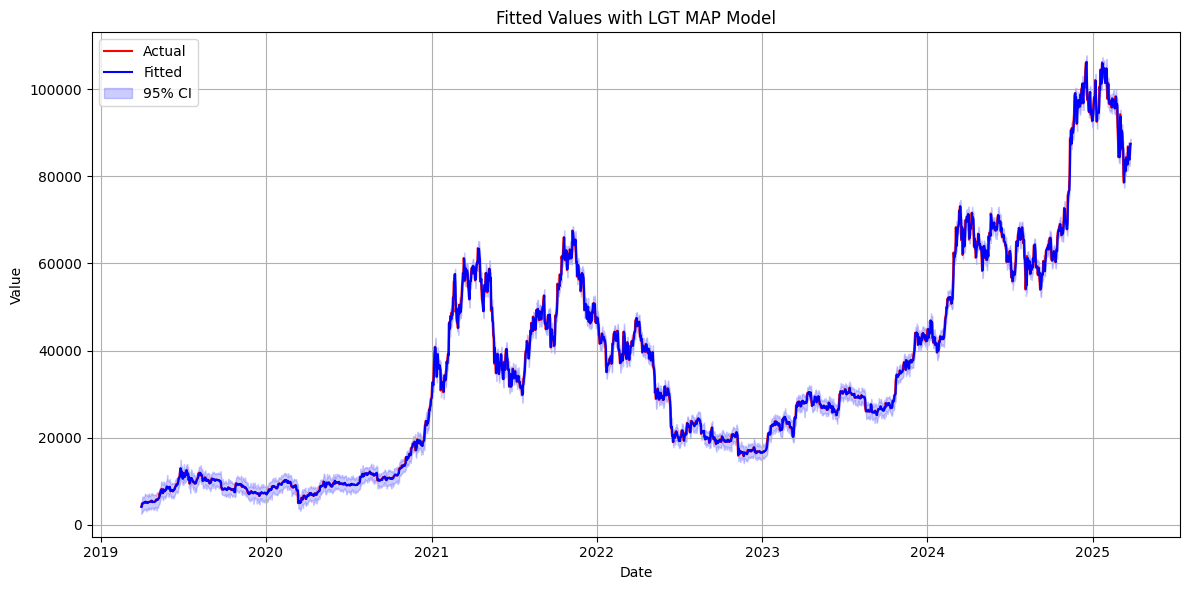

=== LGT MAP (Fitting) Performance ===
MSPE: 1716616.5903
MAE:  783.8450
MAPE: 0.0228
PM:   0.0029
----------------------------------------
LGT MAP fitting time:   0.49 seconds


In [ ]:
start_time_map = time.time()
# Set up for 95% Prediction Intervals
prediction_percentiles = [5, 95]
# Apply LGT Model with no seasonality and 100 bootstrap samples used in inference/prediction intervals
lgt_MAP = LGT(
    response_col='y',
    date_col='Date',
    estimator='stan-map',
    seasonality=None,
    n_bootstrap_draws=100,
    prediction_percentiles=prediction_percentiles,
    seed=8888
)
lgt_MAP.fit(train_data)
# Obtain fitted data for the training part of the time series
lgt_MAP_fitted_df = lgt_MAP.predict(train_data)
end_time_map = time.time()
map_duration = end_time_map - start_time_map
# Derive predictions for the testing part of the time series
lgt_MAP_predicted_df = lgt_MAP.predict(test_data)

# Plot the fitted time series
plt.figure(figsize=(12, 6))
plt.plot(train_data['Date'], train_data['y'], label='Actual', color='red')
plt.plot(lgt_MAP_fitted_df['Date'], lgt_MAP_fitted_df['prediction'], label='Fitted', color='blue')
plt.fill_between(
    lgt_MAP_fitted_df['Date'],
    lgt_MAP_fitted_df['prediction_5'],
    lgt_MAP_fitted_df['prediction_95'],
    color='blue', alpha=0.2, label='95% CI'
)
plt.title('Fitted Values with LGT MAP Model')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ========== evaluation methods ==========
def evaluate_performance(true, pred, model_name="Model"):
    mspe = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-6)))
    pm = (np.sum((true - pred) ** 2) / np.sum((true - np.mean(true)) ** 2))

    print(f"=== {model_name} Performance ===")
    print(f"MSPE: {mspe:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"PM:   {pm:.4f}")
    print("-" * 40)


# ========== Performance Metrics for the Fitted Data ==========
evaluate_performance(train_data['y'], lgt_MAP_fitted_df['prediction'].values, "LGT MAP (Fitting)")
print(f"LGT MAP fitting time:   {map_duration:.2f} seconds")


In [ ]:
# The predictions along with the 90% prediction interval are provided vs observed (column y)
merged_pred_obs = pd.merge(lgt_MAP_predicted_df, test_data, on='Date', how='left')
merged_pred_obs.rename(columns={'y': 'Test Values'}, inplace=True)
print(merged_pred_obs)


        Date  prediction_5    prediction  prediction_95   Test Values
0 2025-03-26  86286.959154  87456.002736   89210.363227  86900.882812
1 2025-03-27  85672.394321  87444.908441   89777.336576  87177.101562
2 2025-03-28  85337.799912  87434.097583   90502.288518  84353.148438
3 2025-03-29  83929.899032  87423.563265   90723.938015  82597.585938
4 2025-03-30  83789.874682  87413.298763   90943.465170  82334.523438
5 2025-03-31  84052.431884  87403.297512   90856.231913  82548.914062
6 2025-04-01  82490.375468  87393.553109   91447.600850  85169.171875


In [ ]:
# Here we evaluate the prediction accuracy of the predictions
y_true = train_data['y'].values
y_pred = lgt_MAP_predicted_df['prediction'].values

# ========== Prediction Evaluation Metrics for the Fitted Data ==========
evaluate_performance(test_data['y'], lgt_MAP_predicted_df['prediction'], "LGT MAP (Prediction)")


=== LGT MAP (Prediction) Performance ===
MSPE: 12495578.9728
MAE:  2983.9133
MAPE: 0.0359
PM:   3.4314
----------------------------------------


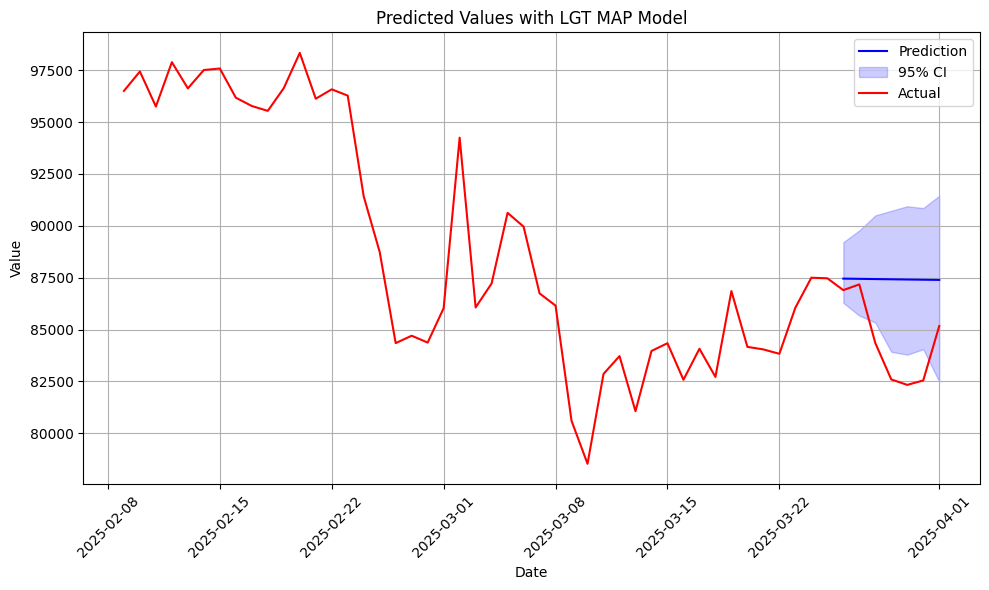

In [ ]:

# Combine the last 5 weeks of training data with the full test set for a smoother actual trend line
actual_extended = pd.concat([train_data.tail(45), test_data], ignore_index=True)

plt.figure(figsize=(10, 6))

# Plot the predicted values (mean forecast)
plt.plot(lgt_MAP_predicted_df['Date'], lgt_MAP_predicted_df['prediction'], label='Prediction', color='blue')

# Plot the 90% prediction interval, if available
if 'prediction_5' in lgt_MAP_predicted_df.columns and 'prediction_95' in lgt_MAP_predicted_df.columns:
    plt.fill_between(lgt_MAP_predicted_df['Date'],
                     lgt_MAP_predicted_df['prediction_5'],
                     lgt_MAP_predicted_df['prediction_95'],
                     color='blue', alpha=0.2, label='95% CI')

# Plot the actual observed values (last 5 weeks of train + test)
plt.plot(actual_extended['Date'], actual_extended['y'], label='Actual', color='red')
# Set the title and axis labels
plt.title('Predicted Values with LGT MAP Model')
plt.xlabel('Date')
plt.ylabel('Value')
# Add legend and improve formatting
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



In the implementation above, we simply tested the use of the LGT Model using Stan-MAP with no seasonality. As we can see, from the first plot of the fitted values from the model that the model fits almost perfectly the observed time series. However, the predictions are well below the observed values. Next we will demonstrate the implementation of the LGT Model but this time using the MCMC estimation approach. Note that the MCMC approach will be more computational expensive -- more than 1 minute to run for one model fit. As we might want to compare multiple models, this might not be computationally feasible.

### LGT Model using MCMC Estimation Approach

2025-11-01 21:30:05 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

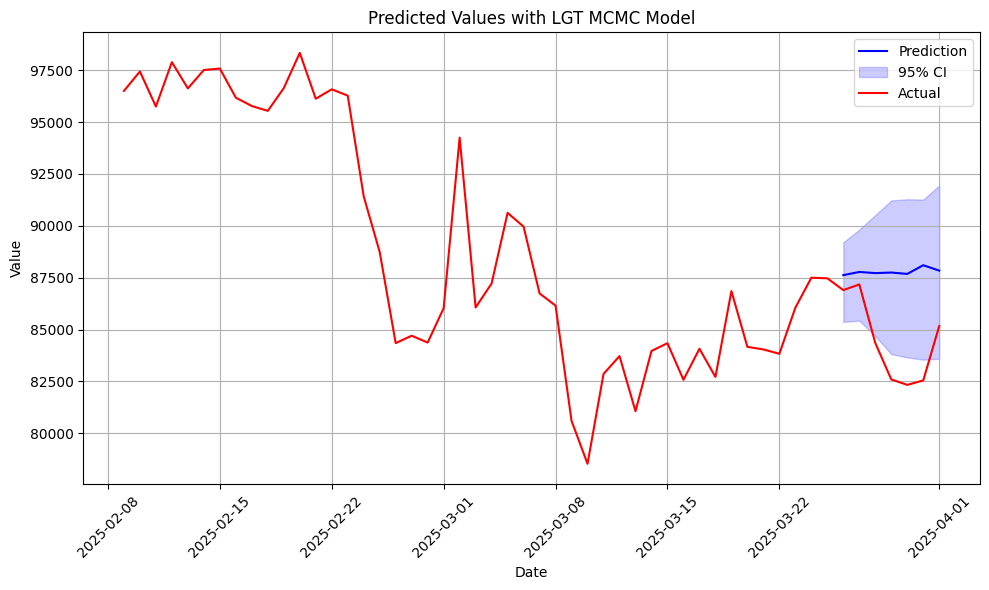

In [ ]:
start_time_mcmc = time.time()
prediction_percentiles = [5, 95]
lgt_mcmc = LGT(
    response_col='y',
    date_col='Date',
    estimator='stan-mcmc',
    #seasonality=180,
    seasonality=None,
    n_bootstrap_draws=100,
    prediction_percentiles=prediction_percentiles,
    # num_warmup = 800,
    # num_sample=200,
    seed=8888,
    stan_mcmc_args={'show_progress': True}
)
 # We have two tunning parameters that we could change although we will keep the default in our implementation
 # These parameters might impact the performance of the model fit and prediction versus the computation time
    # num_warmup : int
    #     Number of samples to warm up and to be discarded, default 900
    # num_sample : int
    #     Number of samples to return, default 100

lgt_mcmc.fit(train_data)
lgt_mcmc_fitted_df = lgt_mcmc.predict(train_data)
end_time_mcmc = time.time()
mcmc_duration = end_time_mcmc - start_time_mcmc

lgt_mcmc_predicted_df = lgt_mcmc.predict(test_data)

plt.figure(figsize=(10, 6))

# Plot the predicted values (mean forecast)
plt.plot(lgt_mcmc_predicted_df['Date'], lgt_mcmc_predicted_df['prediction'], label='Prediction', color='blue')
# Plot the 90% prediction interval, if available
if 'prediction_5' in lgt_mcmc_predicted_df.columns and 'prediction_95' in lgt_mcmc_predicted_df.columns:
    plt.fill_between(lgt_mcmc_predicted_df['Date'],
                     lgt_mcmc_predicted_df['prediction_5'],
                     lgt_mcmc_predicted_df['prediction_95'],
                     color='blue', alpha=0.2, label='95% CI')

# Plot the actual observed values (last 5 weeks of train + test)
plt.plot(actual_extended['Date'], actual_extended['y'], label='Actual', color='red')
# Set the title and axis labels
plt.title('Predicted Values with LGT MCMC Model')
plt.xlabel('Date')
plt.ylabel('Value')
# Add legend and improve formatting
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
# The predictions along with the 90% prediction interval are provided vs observed (column y)
merged_pred_obs = pd.merge(lgt_mcmc_predicted_df, test_data, on='Date', how='left')
merged_pred_obs.rename(columns={'y': 'Test Values'}, inplace=True)
print(merged_pred_obs)

        Date  prediction_5    prediction  prediction_95   Test Values
0 2025-03-26  85368.559037  87623.241736   89204.658430  86900.882812
1 2025-03-27  85430.548524  87776.728787   89819.485774  87177.101562
2 2025-03-28  84688.686241  87721.233148   90520.390916  84353.148438
3 2025-03-29  83816.457650  87748.980541   91224.093255  82597.585938
4 2025-03-30  83658.636871  87681.472095   91279.499727  82334.523438
5 2025-03-31  83551.129188  88101.639723   91266.036100  82548.914062
6 2025-04-01  83594.675727  87841.566841   91948.314484  85169.171875


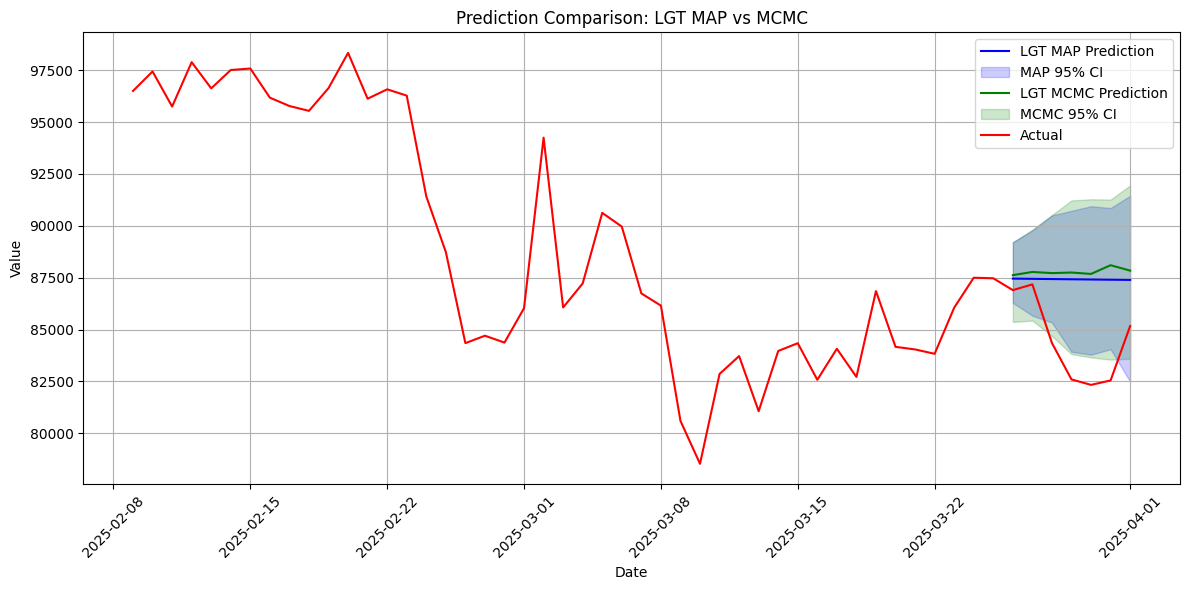

=== LGT MAP (Prediction) Performance ===
MSPE: 12495578.9728
MAE:  2983.9133
MAPE: 0.0359
PM:   3.4314
----------------------------------------
=== LGT MCMC (Prediction) Performance ===
MSPE: 15046647.6092
MAE:  3344.7907
MAPE: 0.0402
PM:   4.1320
----------------------------------------
LGT MAP fitting time:   0.49 seconds
LGT MCMC fitting time:  96.29 seconds


In [ ]:

plt.figure(figsize=(12, 6))

# MAP prediction line and confidence interval
plt.plot(lgt_MAP_predicted_df['Date'], lgt_MAP_predicted_df['prediction'], label='LGT MAP Prediction', color='blue')
plt.fill_between(lgt_MAP_predicted_df['Date'], lgt_MAP_predicted_df['prediction_5'], lgt_MAP_predicted_df['prediction_95'],
                 color='blue', alpha=0.2, label='MAP 95% CI')

# MCMC prediction line and confidence interval
plt.plot(lgt_mcmc_predicted_df['Date'], lgt_mcmc_predicted_df['prediction'], label='LGT MCMC Prediction', color='green')
plt.fill_between(lgt_mcmc_predicted_df['Date'], lgt_mcmc_predicted_df['prediction_5'], lgt_mcmc_predicted_df['prediction_95'],
                 color='green', alpha=0.2, label='MCMC 95% CI')

# Actual values
plt.plot(actual_extended['Date'], actual_extended['y'], label='Actual', color='red')

plt.title('Prediction Comparison: LGT MAP vs MCMC')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
# ========== Performance Metrics for Predictions: Compare the two models ==========
evaluate_performance(test_data['y'], lgt_MAP_predicted_df['prediction'], "LGT MAP (Prediction)")
evaluate_performance(test_data['y'], lgt_mcmc_predicted_df['prediction'], "LGT MCMC (Prediction)")

# ========== Estimation Time Comparison ==========
print(f"LGT MAP fitting time:   {map_duration:.2f} seconds")
print(f"LGT MCMC fitting time:  {mcmc_duration:.2f} seconds")

In our latest comparison, we evaluated the performance of the LGT MAP and LGT MCMC estimation methods. The MAP model outperforms the MCMC model across all accuracy measures. In terms of computational time, the MAP method is significantly faster, with a fitting time of only 0.55 seconds, compared to the MCMC model's fitting time of 91.37 seconds.

Please note that `n_bootstrap_draws` can affect the results of MCMC. We only considered here to be 100 because of the computational effort needed when fitting using the MCMC approach.

Because of the computational effort needed to fit using the MCMC estimation approach, we will continue using the MAP approach.

In [ ]:
# === LGT MAP Model Parameters ===
print("=== LGT MAP Parameters ===")
map_params = lgt_MAP.get_point_posteriors()
print(f"slope_sm_input: {map_params['map']['slp_sm'][0]:.4f}")
print(f"level_sm_input: {map_params['map']['lev_sm'][0]:.4f}")
print("----------------------------------------")

# === LGT MCMC Model Parameters ===
print("=== LGT MCMC Parameters ===")
mcmc_params = lgt_mcmc.get_point_posteriors()
print(f"slope_sm_input: {mcmc_params['mean']['slp_sm'][0]:.4f}")
print(f"level_sm_input: {mcmc_params['mean']['lev_sm'][0]:.4f}")
print("----------------------------------------")

=== LGT MAP Parameters ===
slope_sm_input: 0.0288
level_sm_input: 0.9426
----------------------------------------
=== LGT MCMC Parameters ===
slope_sm_input: 0.5154
level_sm_input: 0.8726
----------------------------------------


Although the results from both models are similar, there are some differences in the trend-related parameters. A larger value puts more weight on the current level and slope.

### LGT Model: Seasonality analysis

2025-11-01 21:31:50 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


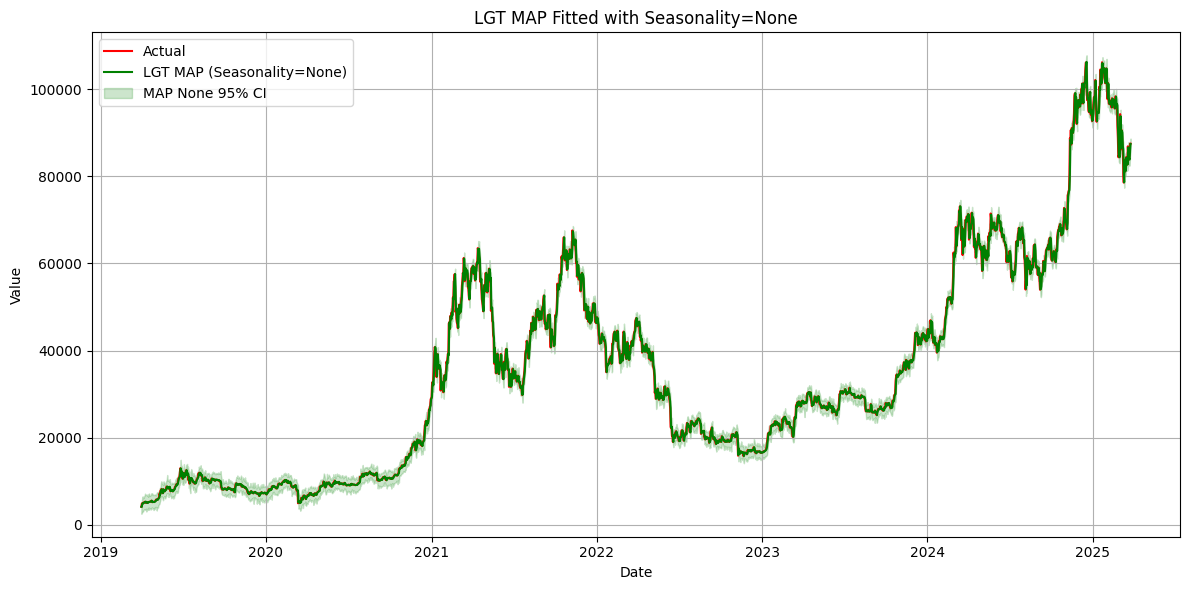

2025-11-01 21:31:52 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


=== LGT MAP (Seasonality=None) Performance ===
MSPE: 1716616.5903
MAE:  783.8450
MAPE: 0.0228
PM:   0.0029
----------------------------------------


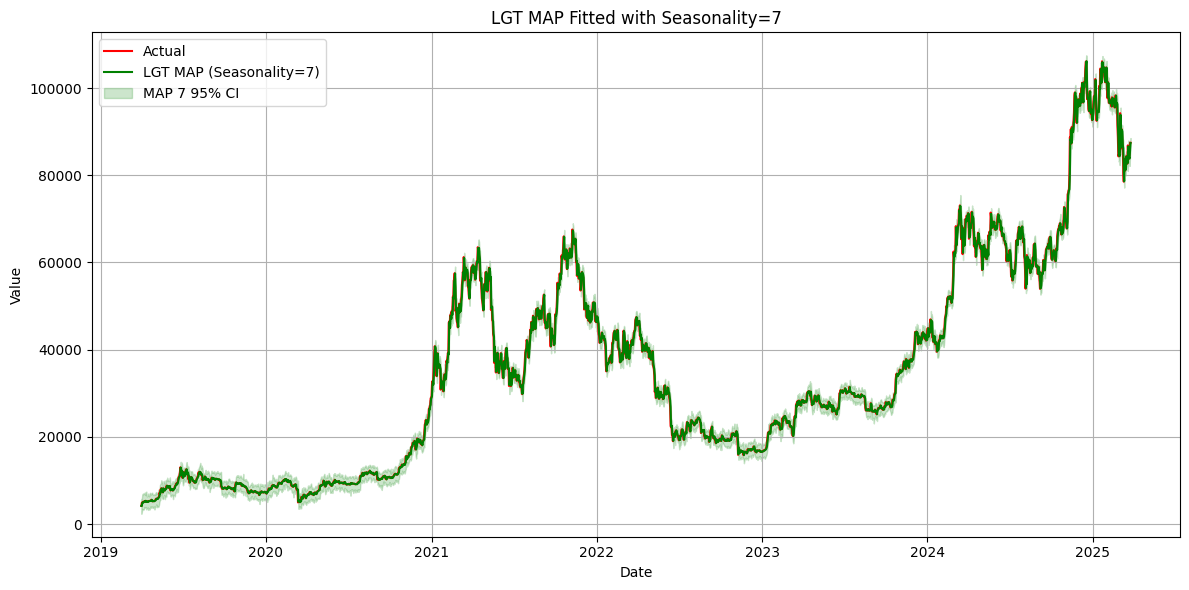

2025-11-01 21:31:55 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


=== LGT MAP (Seasonality=7) Performance ===
MSPE: 1717149.8295
MAE:  783.9178
MAPE: 0.0228
PM:   0.0029
----------------------------------------


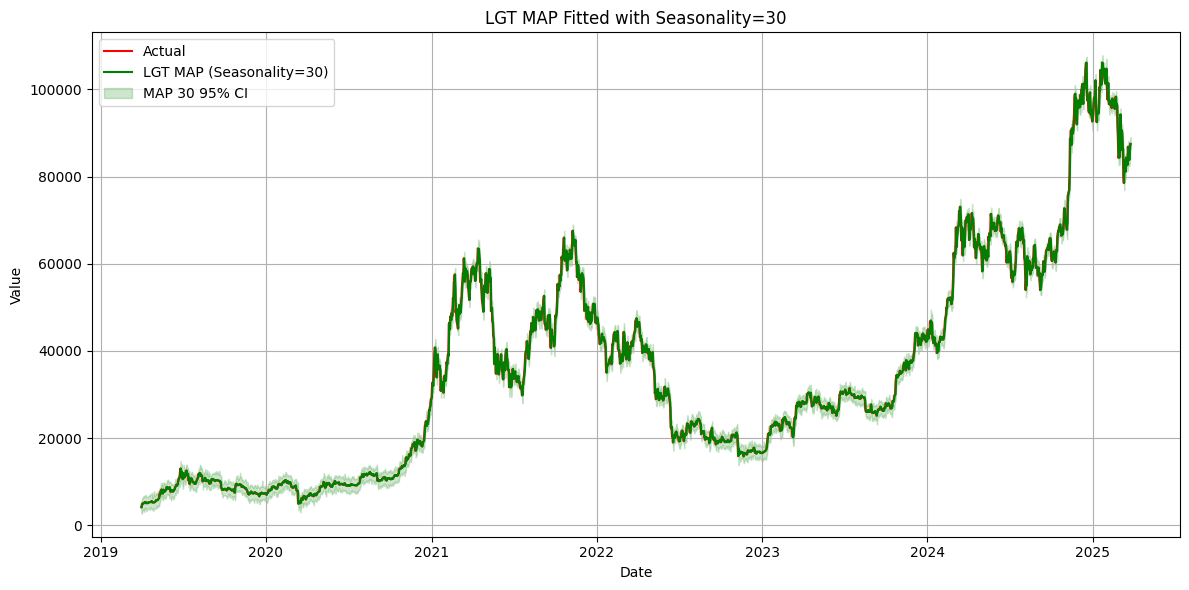

2025-11-01 21:31:57 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


=== LGT MAP (Seasonality=30) Performance ===
MSPE: 1721839.9776
MAE:  786.8934
MAPE: 0.0229
PM:   0.0029
----------------------------------------


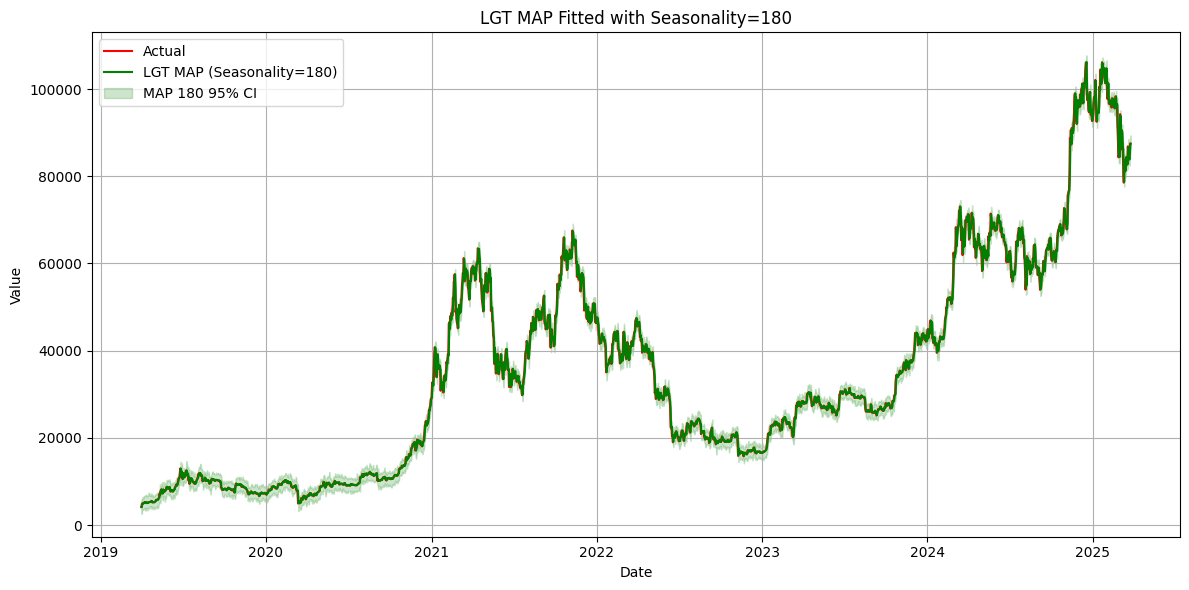

2025-11-01 21:31:59 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


=== LGT MAP (Seasonality=180) Performance ===
MSPE: 1716319.4522
MAE:  783.6427
MAPE: 0.0228
PM:   0.0029
----------------------------------------


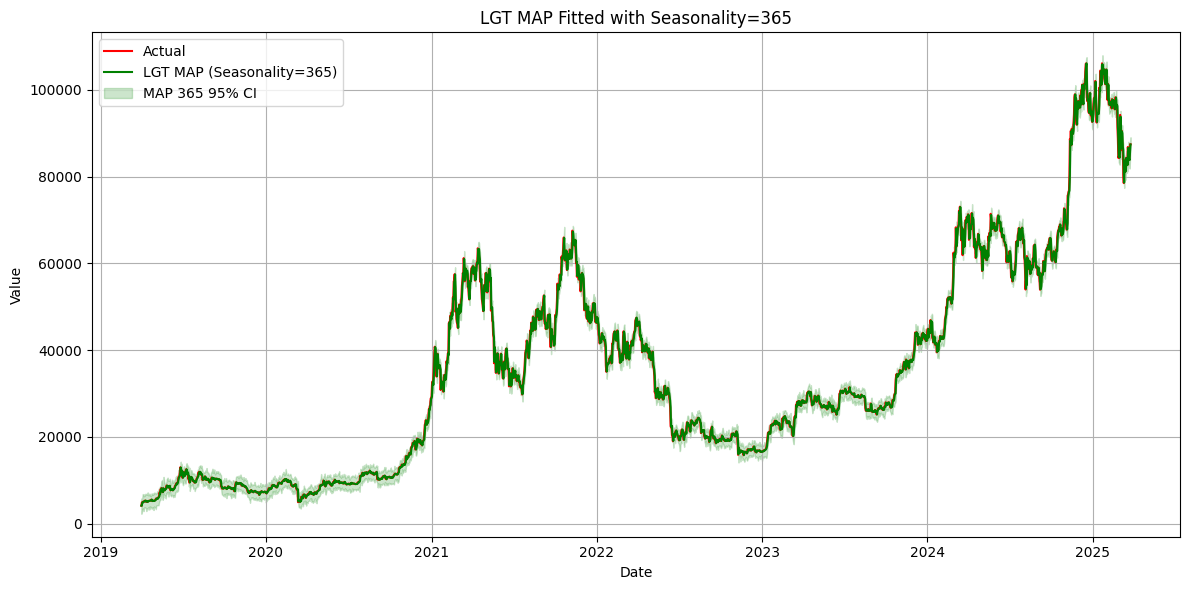

=== LGT MAP (Seasonality=365) Performance ===
MSPE: 1717089.9886
MAE:  783.7221
MAPE: 0.0228
PM:   0.0029
----------------------------------------


In [ ]:
# === LGT Model with Seasonality Analysis ===

seasonality_values = [None, 7, 30, 180, 365]
lgt_models = {}

for seasonality in seasonality_values:

    # Convert seasonality
    seasonality_str = "none" if seasonality is None else str(seasonality)

    # Create a unique name for each model
    model_name = f"lgt_map_{seasonality_str}"

    model = LGT(
        response_col='y',
        date_col='Date',
        estimator='stan-map',
        n_bootstrap_draws=100,
        seasonality=seasonality,
        prediction_percentiles=[5, 95],
        seed=8888
    )
    model.fit(train_data)

    globals()[model_name] = model
    lgt_models[seasonality] = model
    map_fitted = model.predict(train_data)

# ========== Fitting Plot ==========
    plt.figure(figsize=(12, 6))
    plt.plot(train_data['Date'], train_data['y'], label='Actual', color='red')
    plt.plot(map_fitted['Date'], map_fitted['prediction'], label=f'LGT MAP (Seasonality={seasonality})', color='green')

    if 'prediction_5' in map_fitted.columns and 'prediction_95' in map_fitted.columns:
        plt.fill_between(map_fitted['Date'],
                         map_fitted['prediction_5'],
                         map_fitted['prediction_95'],
                         color='green', alpha=0.2, label=f'MAP {seasonality} 95% CI')

    plt.title(f'LGT MAP Fitted with Seasonality={seasonality}')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

 # ========== Performance Metrics ==========
    evaluate_performance(train_data['y'], map_fitted['prediction'], f"LGT MAP (Seasonality={seasonality})")


Although the differences across seasonality settings are not visually apparent in the plots, the model without seasonality demonstrates slightly better performance based on metrics . In the next step, we will evaluate the predictive performance of each seasonality setting.

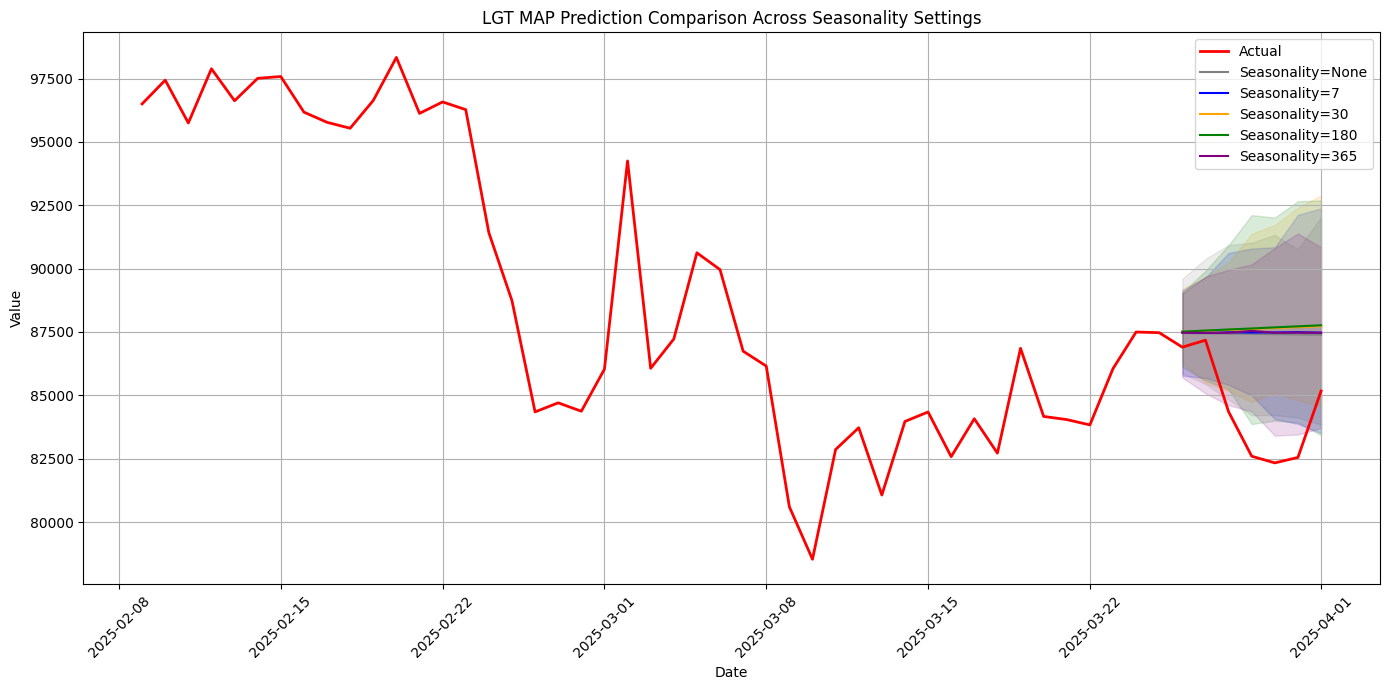

=== LGT MAP (Prediction, Seasonality=None) Performance ===
MSPE: 12495578.9728
MAE:  2983.9133
MAPE: 0.0359
PM:   3.4314
----------------------------------------
=== LGT MAP (Prediction, Seasonality=7) Performance ===
MSPE: 12904962.6821
MAE:  3042.0954
MAPE: 0.0366
PM:   3.5438
----------------------------------------
=== LGT MAP (Prediction, Seasonality=30) Performance ===
MSPE: 13922096.0012
MAE:  3178.0255
MAPE: 0.0382
PM:   3.8232
----------------------------------------
=== LGT MAP (Prediction, Seasonality=180) Performance ===
MSPE: 14080862.2636
MAE:  3199.3926
MAPE: 0.0384
PM:   3.8668
----------------------------------------
=== LGT MAP (Prediction, Seasonality=365) Performance ===
MSPE: 12929669.4051
MAE:  3040.7960
MAPE: 0.0365
PM:   3.5506
----------------------------------------


In [ ]:
# ========== MAP Predictions for All Seasonality Settings ==========
plt.figure(figsize=(14, 7))

seasonality_preds = {}

colors = {
    None: 'gray',
    7: 'blue',
    30: 'orange',
    180: 'green',
    365: 'purple'
}

# Combine recent train data + test data for plotting
actual_extended = pd.concat([train_data.tail(45), test_data], ignore_index=True)

# Plot actual values
plt.plot(actual_extended['Date'], actual_extended['y'], label='Actual', color='red', linewidth=2)

# Loop through each seasonality model and predict
for seasonality in [None, 7, 30, 180, 365]:
    model = lgt_models[seasonality]

    #Prediction
    pred = model.predict(test_data)
    seasonality_preds[seasonality] = pred

    # Plot prediction
    plt.plot(pred['Date'], pred['prediction'],
             label=f'Seasonality={seasonality}', color=colors[seasonality])

    # Plot confidence interval
    plt.fill_between(pred['Date'], pred['prediction_5'], pred['prediction_95'],
                     color=colors[seasonality], alpha=0.15)

plt.title('LGT MAP Prediction Comparison Across Seasonality Settings')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# ========== Prediction Evaluation Metrics ==========
for seasonality, pred in seasonality_preds.items():
    evaluate_performance(test_data['y'], pred['prediction'], f"LGT MAP (Prediction, Seasonality={seasonality})")


From a forecasting performance perspective, the non-seasonal model showed the best results, consistent with performance during the fitting phase. Therefore, we will retain the non-seasonal setting for comparison in the subsequent analysis.

### DLT Model: Trend Analysis

Next, we will run experiments on the DLT model, testing each of its four global trend options—loglinear, linear, flat, and logistic—separately.

2025-06-18 15:45:13 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.


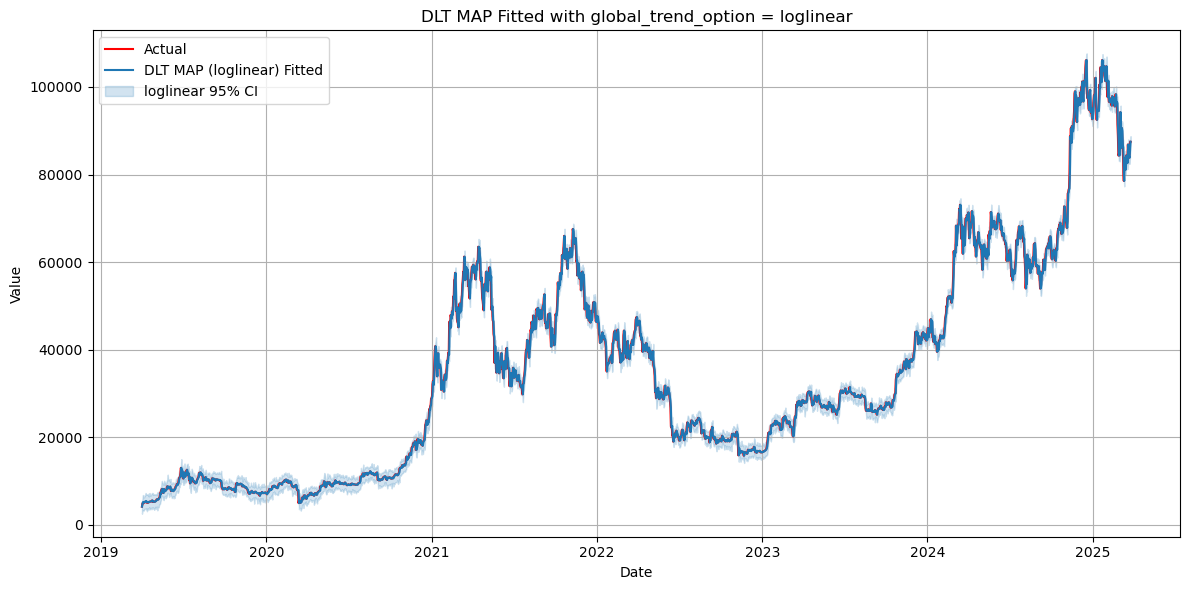

2025-06-18 15:45:15 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.


=== DLT MAP (Fitting, trend_option=loglinear) Performance ===
MSPE: 1722899.9478
MAE:  786.5825
MAPE: 0.0228
PM:   0.0029
----------------------------------------


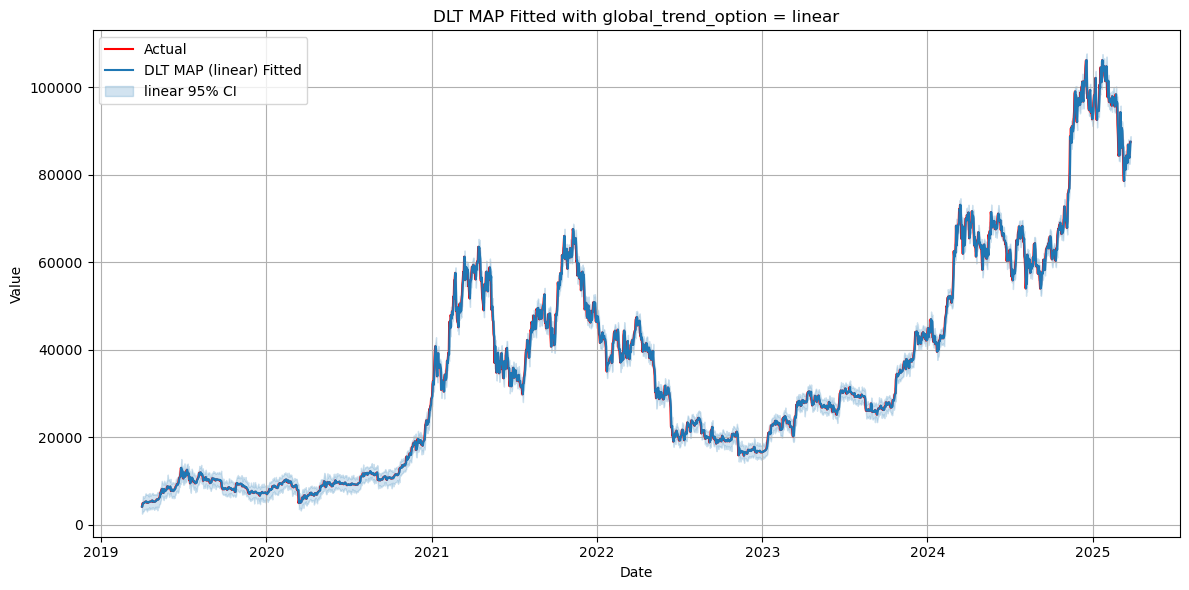

2025-06-18 15:45:16 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.


=== DLT MAP (Fitting, trend_option=linear) Performance ===
MSPE: 1721785.0900
MAE:  787.1222
MAPE: 0.0229
PM:   0.0029
----------------------------------------


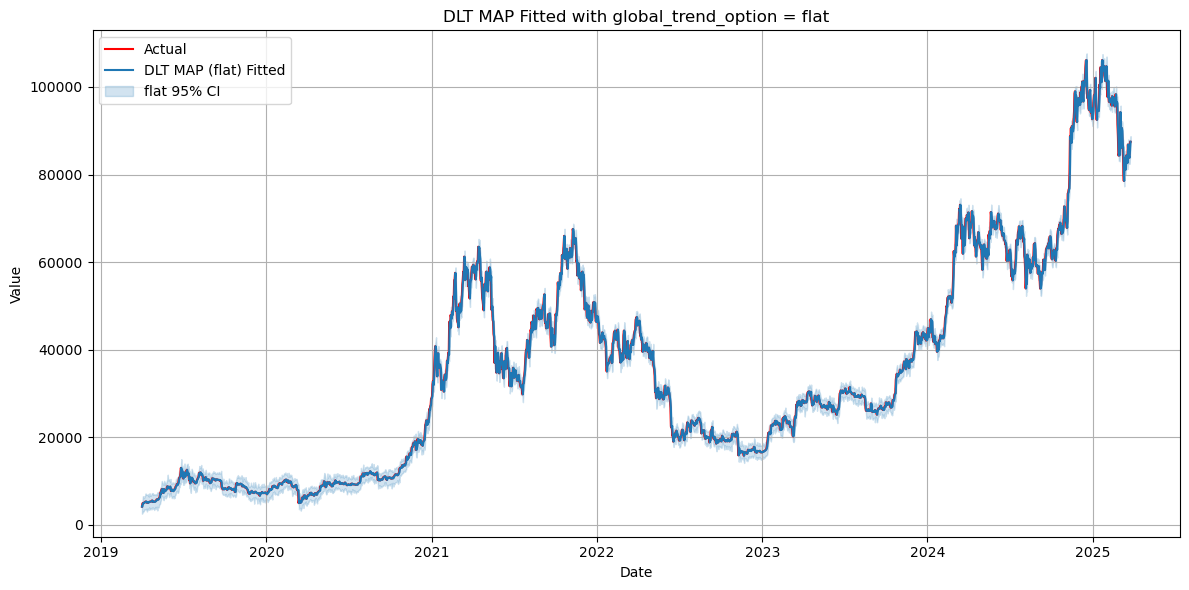

2025-06-18 15:45:17 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.


=== DLT MAP (Fitting, trend_option=flat) Performance ===
MSPE: 1723163.2472
MAE:  786.8003
MAPE: 0.0229
PM:   0.0029
----------------------------------------


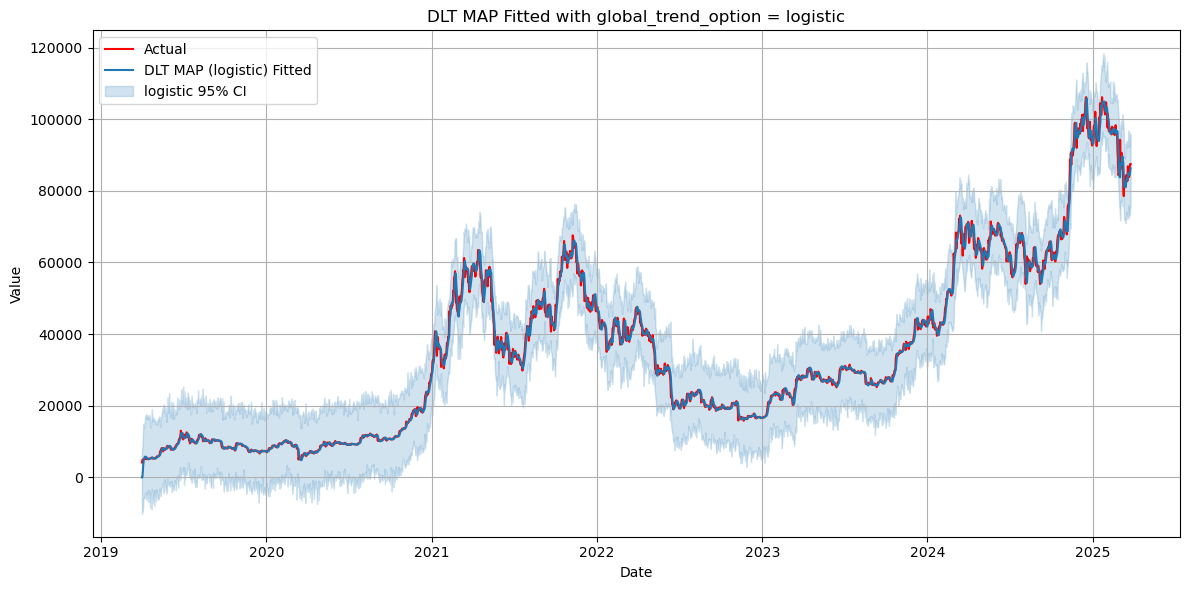

=== DLT MAP (Fitting, trend_option=logistic) Performance ===
MSPE: 2409526.1024
MAE:  975.8716
MAPE: 0.0300
PM:   0.0040
----------------------------------------


In [ ]:
# === DLT Model with Global Trend Option Analysis ===

trend_options = ['loglinear', 'linear', 'flat', 'logistic']
dlt_models = {}

for opt in trend_options:
    model_name = f"dlt_map_{opt}"

    # initialize & fit
    dlt_map = DLT(
        seasonality=None,
        response_col='y',
        date_col='Date',
        estimator='stan-map',
        seed=8888,
        global_trend_option=opt,
        #damped_factor=0.8,
        n_bootstrap_draws=100,
        prediction_percentiles=[5, 95],
    )

    dlt_map.fit(train_data)

    # save to globals and dict
    globals()[model_name] = dlt_map
    dlt_models[opt] = dlt_map

    # get fitted (train) predictions
    dlt_fitted = dlt_map.predict(train_data,point_method="median")

    # ========== Fitting Plot ==========
    plt.figure(figsize=(12, 6))
    plt.plot(train_data['Date'], train_data['y'], label='Actual', color='red')
    plt.plot(dlt_fitted['Date'], dlt_fitted['prediction'],
             label=f'DLT MAP ({opt}) Fitted', color='C0')

    if 'prediction_5' in dlt_fitted.columns and 'prediction_95' in dlt_fitted.columns:
        plt.fill_between(
            dlt_fitted['Date'],
            dlt_fitted['prediction_5'],
            dlt_fitted['prediction_95'],
            color='C0', alpha=0.2,
            label=f'{opt} 95% CI'
        )

    plt.title(f'DLT MAP Fitted with global_trend_option = {opt}')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ========== Performance Metrics ==========
    evaluate_performance(
        train_data['y'],
        dlt_fitted['prediction'],
        f"DLT MAP (Fitting, trend_option={opt})"
    )


 Numerically, the loglinear option performs relatively better

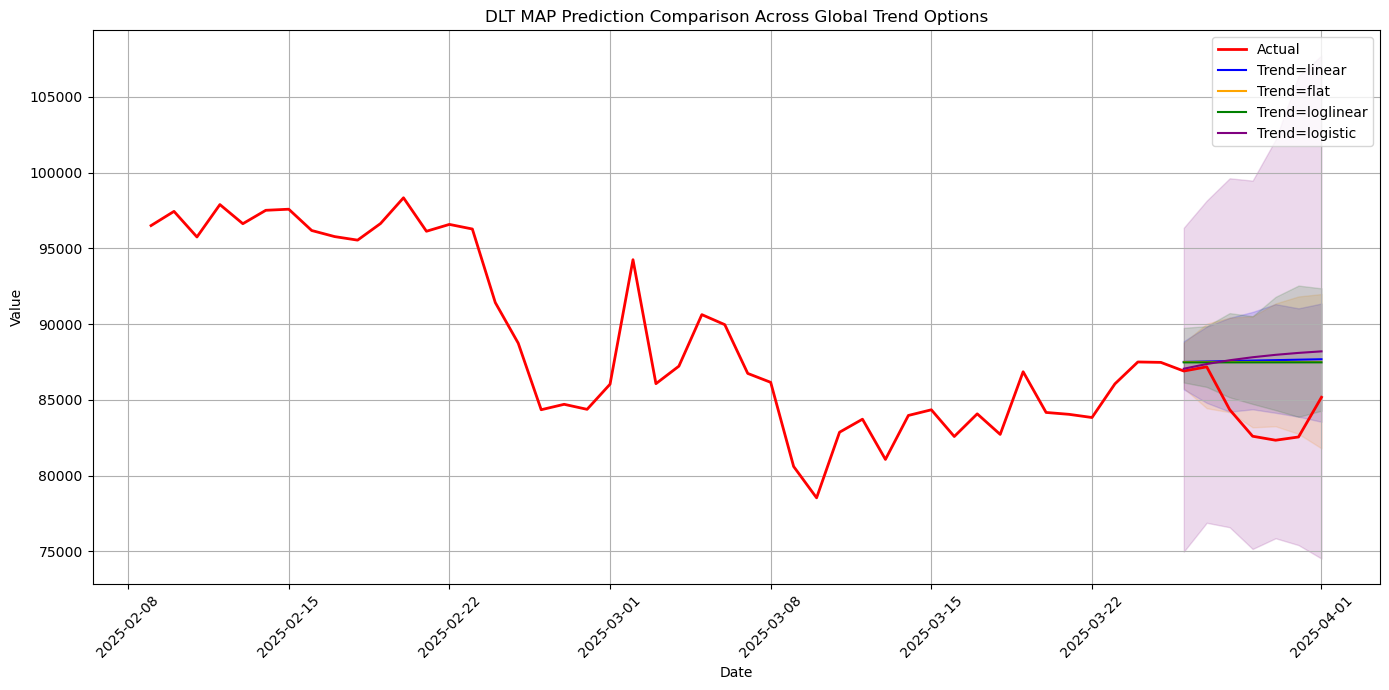

=== DLT MAP (Prediction, Trend=linear) Performance ===
MSPE: 13703407.2381
MAE:  3149.5436
MAPE: 0.0378
PM:   3.7631
----------------------------------------
=== DLT MAP (Prediction, Trend=flat) Performance ===
MSPE: 12831942.7856
MAE:  3031.5698
MAPE: 0.0364
PM:   3.5238
----------------------------------------
=== DLT MAP (Prediction, Trend=loglinear) Performance ===
MSPE: 12841518.6508
MAE:  3032.8880
MAPE: 0.0364
PM:   3.5264
----------------------------------------
=== DLT MAP (Prediction, Trend=logistic) Performance ===
MSPE: 15653330.0668
MAE:  3289.2319
MAPE: 0.0396
PM:   4.2986
----------------------------------------


In [ ]:
# ========== DLT MAP Predictions for All Trend Settings ==========
plt.figure(figsize=(14, 7))

trend_preds = {}

colors = {
    'linear': 'blue',
    'flat': 'orange',
    'loglinear': 'green',
    'logistic': 'purple'
}

actual_extended = pd.concat([train_data.tail(45), test_data], ignore_index=True)


plt.plot(actual_extended['Date'], actual_extended['y'], label='Actual', color='red', linewidth=2)


for trend in ['linear', 'flat', 'loglinear', 'logistic']:
    model = dlt_models[trend]
    pred = model.predict(test_data)
    trend_preds[trend] = pred
    plt.plot(pred['Date'], pred['prediction'], label=f'Trend={trend}', color=colors[trend])

    plt.fill_between(pred['Date'], pred['prediction_5'], pred['prediction_95'],
                     color=colors[trend], alpha=0.15)

plt.title('DLT MAP Prediction Comparison Across Global Trend Options')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# ========== Prediction Evaluation ==========
for trend, pred in trend_preds.items():
    evaluate_performance(test_data['y'], pred['prediction'], f"DLT MAP (Prediction, Trend={trend})")


Both the log-linear and flat trend options perform well during the fitting process



# Regression Analysis

## Feature engineering

In this section, we focus on the regression component of the DLT model. We incorporated **S&P 500 index** and **gold prices** as external data sources.  

For data processing, we first adjusted the **date** to ensure consistency across all three datasets. Additionally, since **S&P 500** and **gold prices** lack data on weekends, we filled in the missing weekend values using **Friday’s prices**. In this regard, Uber’s DLT model is not as advanced as LinkedIn’s Silverkite model, which offers better simulation and imputation capabilities.

In [ ]:
# Load the new data files
btc_df = df
# gold_df_new = pd.read_csv('data/Gold.csv')
# sp500_df = pd.read_csv('data/sp500.csv', parse_dates=['Date'])
gold_df_new = pd.read_csv('Gold.csv')
sp500_df = pd.read_csv('sp500.csv', parse_dates=['Date'])

# Clean up column names by stripping extra spaces
gold_df_new.columns = gold_df_new.columns.str.strip()

# Rename columns for clarity
sp500_df.rename(columns={'Close/Last': 'SP500'}, inplace=True)
gold_df_new.rename(columns={'Close': 'Gold'}, inplace=True)

# Select only 'Close' columns for each dataset
btc_df = btc_df[['Date', 'y']]
sp500_df = sp500_df[['Date', 'SP500']]
gold_df_new = gold_df_new[['Date', 'Gold']]

# Rename the 'Close' column in btc_df to 'BTC'
btc_df.rename(columns={'Close': 'BTC'}, inplace=True)

# Ensure all 'Date' columns are of datetime type for consistency
btc_df['Date'] = pd.to_datetime(btc_df['Date'])
sp500_df['Date'] = pd.to_datetime(sp500_df['Date'])
gold_df_new['Date'] = pd.to_datetime(gold_df_new['Date'])


# Merge datasets based on the Date column
merged_df = btc_df.merge(sp500_df, on='Date', how='left').merge(gold_df_new, on='Date', how='left')

# Add weekday name column
merged_df['Weekday'] = merged_df['Date'].dt.day_name()

# Sort the dataframe by Date
merged_df.sort_values('Date', inplace=True)

# Extract a pre-ffill version for comparison
pre_ffill_clip = merged_df[(merged_df['Date'] >= '2024-12-30') & (merged_df['Date'] <= '2025-01-07')].copy()



# Check for missing values before filling
print("Missing values before filling:\n", merged_df.isnull().sum())

# Fill missing values using forward fill
merged_df.fillna(method='ffill', inplace=True)

# Extract a post-ffill version
post_ffill_clip = merged_df[(merged_df['Date'] >= '2024-12-30') & (merged_df['Date'] <= '2025-01-07')]


# Check for missing values after filling
print("Missing values after filling:\n", merged_df.isnull().sum())


Missing values before filling:
 Date         0
y            0
SP500      683
Gold       682
Weekday      0
dtype: int64
Missing values after filling:
 Date       0
y          0
SP500      0
Gold       0
Weekday    0
dtype: int64


/tmp/ipython-input-3079474921.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df.fillna(method='ffill', inplace=True)


In [ ]:
merged_df

,Date,y,SP500,Gold,Weekday
0,2019-04-01,4158.183105,2867.19,1288.400024,Monday
1,2019-04-02,4879.877930,2867.24,1290.000000,Tuesday
2,2019-04-03,4973.021973,2873.40,1289.900024,Wednesday
3,2019-04-04,4922.798828,2879.39,1289.000000,Thursday
4,2019-04-05,5036.681152,2892.74,1290.400024,Friday
...,...,...,...,...,...
2188,2025-03-28,84353.148438,5580.94,3086.500000,Friday
2189,2025-03-29,82597.585938,5580.94,3086.500000,Saturday
2190,2025-03-30,82334.523438,5580.94,3086.500000,Sunday
2191,2025-03-31,82548.914062,5611.85,3122.800049,Monday


In [ ]:
print(merged_df.head(10))

        Date            y    SP500         Gold    Weekday
0 2019-04-01  4158.183105  2867.19  1288.400024     Monday
1 2019-04-02  4879.877930  2867.24  1290.000000    Tuesday
2 2019-04-03  4973.021973  2873.40  1289.900024  Wednesday
3 2019-04-04  4922.798828  2879.39  1289.000000   Thursday
4 2019-04-05  5036.681152  2892.74  1290.400024     Friday
5 2019-04-06  5059.817383  2892.74  1290.400024   Saturday
6 2019-04-07  5198.896973  2892.74  1290.400024     Sunday
7 2019-04-08  5289.770996  2895.77  1297.099976     Monday
8 2019-04-09  5204.958496  2878.20  1303.500000    Tuesday
9 2019-04-10  5324.551758  2888.21  1309.099976  Wednesday


In [ ]:
print(merged_df.tail(10))

           Date             y    SP500         Gold    Weekday
2183 2025-03-23  86054.375000  5667.56  3018.199951     Sunday
2184 2025-03-24  87498.914062  5767.57  3013.100098     Monday
2185 2025-03-25  87471.703125  5776.65  3023.699951    Tuesday
2186 2025-03-26  86900.882812  5712.20  3020.899902  Wednesday
2187 2025-03-27  87177.101562  5693.31  3060.199951   Thursday
2188 2025-03-28  84353.148438  5580.94  3086.500000     Friday
2189 2025-03-29  82597.585938  5580.94  3086.500000   Saturday
2190 2025-03-30  82334.523438  5580.94  3086.500000     Sunday
2191 2025-03-31  82548.914062  5611.85  3122.800049     Monday
2192 2025-04-01  85169.171875  5633.07  3118.899902    Tuesday


In [ ]:

merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df = merged_df[['Date', 'y', 'SP500', 'Gold']]

train_data_r = merged_df.iloc[:-7].reset_index(drop=True)
test_data_r = merged_df.iloc[-7:].reset_index(drop=True)


print(f"training: {train_data_r['Date'].min()} ~ {train_data_r['Date'].max()}")
print(f"testing: {test_data_r['Date'].min()} ~ {test_data_r['Date'].max()}")


print(train_data_r.head())
print(test_data_r.head())

training: 2019-04-01 00:00:00 ~ 2025-03-25 00:00:00
testing: 2025-03-26 00:00:00 ~ 2025-04-01 00:00:00
        Date            y    SP500         Gold
0 2019-04-01  4158.183105  2867.19  1288.400024
1 2019-04-02  4879.877930  2867.24  1290.000000
2 2019-04-03  4973.021973  2873.40  1289.900024
3 2019-04-04  4922.798828  2879.39  1289.000000
4 2019-04-05  5036.681152  2892.74  1290.400024
        Date             y    SP500         Gold
0 2025-03-26  86900.882812  5712.20  3020.899902
1 2025-03-27  87177.101562  5693.31  3060.199951
2 2025-03-28  84353.148438  5580.94  3086.500000
3 2025-03-29  82597.585938  5580.94  3086.500000
4 2025-03-30  82334.523438  5580.94  3086.500000


In [ ]:
# === Print Pre-ffill ===
print("\nSample Clip (Before Forward Fill):")
print(pre_ffill_clip.rename(columns={'y': 'BTC'})[['Date', 'Weekday', 'BTC', 'SP500', 'Gold']].to_string(index=False))

# === Print Post-ffill ===
print("\nSample Clip (After Forward Fill):")
print(post_ffill_clip.rename(columns={'y': 'BTC'})[['Date', 'Weekday', 'BTC', 'SP500', 'Gold']].to_string(index=False))


Sample Clip (Before Forward Fill):
      Date   Weekday           BTC   SP500        Gold
2024-12-30    Monday  92643.210938 5906.94 2606.100098
2024-12-31   Tuesday  93429.203125 5881.63 2629.199951
2025-01-01 Wednesday  94419.757812     NaN         NaN
2025-01-02  Thursday  96886.875000 5868.55 2658.899902
2025-01-03    Friday  98107.429688 5942.47 2645.000000
2025-01-04  Saturday  98236.226562     NaN         NaN
2025-01-05    Sunday  98314.960938     NaN         NaN
2025-01-06    Monday 102078.085938 5975.38 2638.399902
2025-01-07   Tuesday  96922.703125 5909.03 2656.699951

Sample Clip (After Forward Fill):
      Date   Weekday           BTC   SP500        Gold
2024-12-30    Monday  92643.210938 5906.94 2606.100098
2024-12-31   Tuesday  93429.203125 5881.63 2629.199951
2025-01-01 Wednesday  94419.757812 5881.63 2629.199951
2025-01-02  Thursday  96886.875000 5868.55 2658.899902
2025-01-03    Friday  98107.429688 5942.47 2645.000000
2025-01-04  Saturday  98236.226562 5942.47 2645.0

### Lag Analysis: Data Generation

In [ ]:
# Synchronous data (original merged_df) includes: BTC_t, Gold_t, SP500_t

# Construct lag-1 features for Gold and SP500
lag1_df = merged_df[['Date', 'y', 'Gold', 'SP500']].copy()
lag1_df.rename(columns={'Gold': 'Gold_t-1', 'SP500': 'SP500_t-1'}, inplace=True)
lag1_df['Gold_t-1'] = lag1_df['Gold_t-1'].shift(1)
lag1_df['SP500_t-1'] = lag1_df['SP500_t-1'].shift(1)


# Construct combined lag-1 and lag-2 features for Gold and SP500
lag2_full_df = merged_df[['Date', 'y', 'Gold', 'SP500']].copy()

# Create lag-1 and lag-2 variables
lag2_full_df['Gold_t-1'] = lag2_full_df['Gold'].shift(1)
lag2_full_df['SP500_t-1'] = lag2_full_df['SP500'].shift(1)
lag2_full_df['Gold_t-2'] = lag2_full_df['Gold'].shift(2)
lag2_full_df['SP500_t-2'] = lag2_full_df['SP500'].shift(2)


# Select only required columns
lag1_df = lag1_df[['Date', 'y', 'Gold_t-1', 'SP500_t-1']]
lag2_full_df = lag2_full_df[['Date', 'y', 'Gold_t-1', 'Gold_t-2', 'SP500_t-1', 'SP500_t-2']]

# Drop rows with missing values (mainly first 1 or 2 rows due to shifting)
lag1_df.dropna(inplace=True)
lag2_full_df.dropna(inplace=True)



In [ ]:
print("Lag-1 Data Sample:")
lag1_df.head()

Lag-1 Data Sample:


,Date,y,Gold_t-1,SP500_t-1
1,2019-04-02,4879.877930,1288.400024,2867.19
2,2019-04-03,4973.021973,1290.000000,2867.24
3,2019-04-04,4922.798828,1289.900024,2873.40
4,2019-04-05,5036.681152,1289.000000,2879.39
5,2019-04-06,5059.817383,1290.400024,2892.74


## Models

In the regression part of DLT experiments, we will build and compare three models:

1. **DLT_Base**: This baseline model uses the same setting as in our previous experiments—specifically, a no seasonal cycle and loglinear global trend, which delivered the best overall fit; all other settings remain unchanged.

2. **DLT_Regression Model with S&P 500 and Gold**: Starting from the dlt_base configuration, we augment the model with two external regressors—the S&P 500 and gold prices—to assess their incremental predictive value.

3. **Refined DLT_Regression Model**: Building on the DLT Regression Model, this version incorporates informative priors to further stabilize estimation and improve the performance.

### Contemporaneous

2025-11-01 21:32:35 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


Training DLT (No Regressors)


2025-11-01 21:32:35 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


Training DLT (With Regressors)


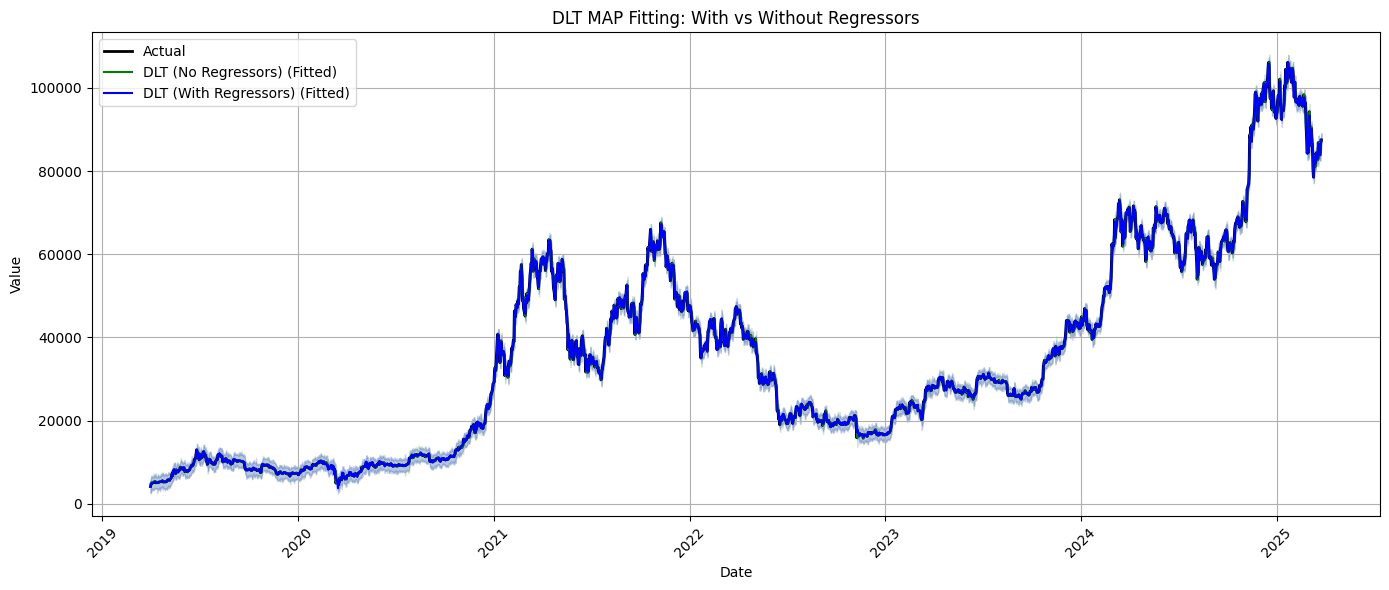

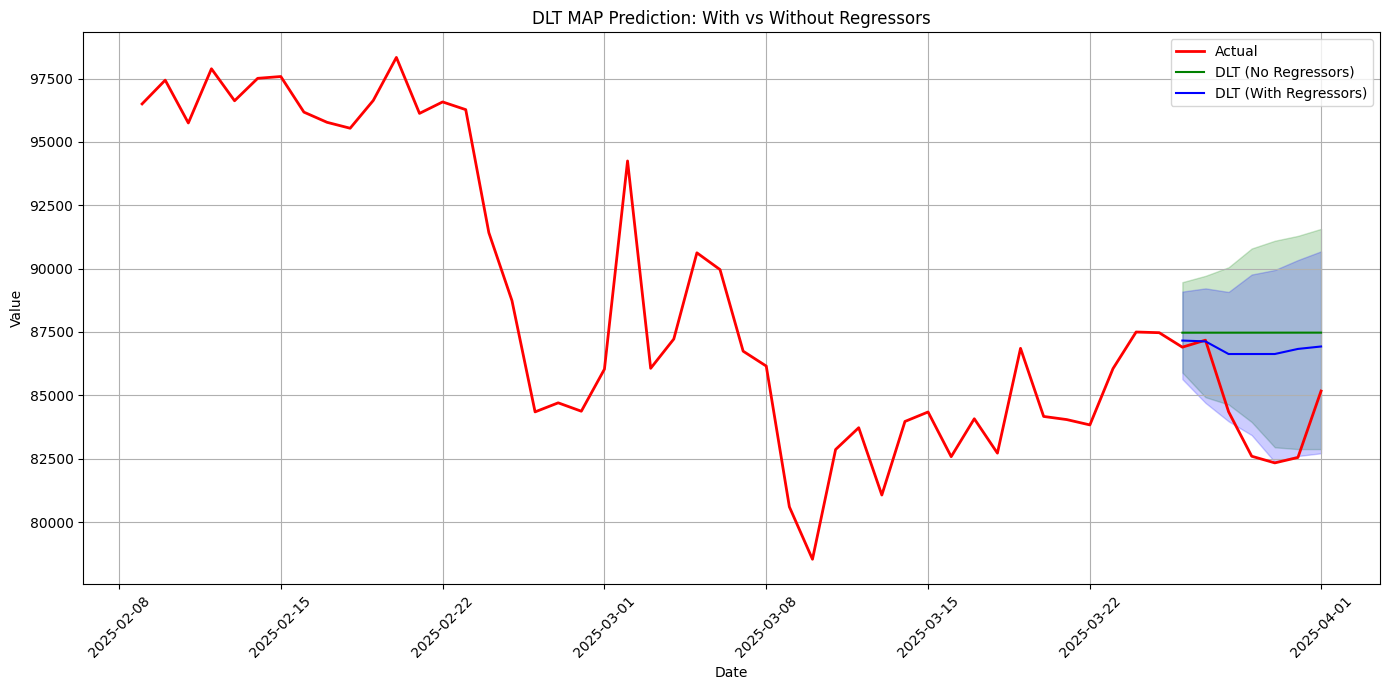

=== DLT (No Regressors) Performance ===
MSPE: 12841378.5923
MAE:  3032.8649
MAPE: 0.0364
PM:   3.5264
----------------------------------------
=== DLT (With Regressors) Performance ===
MSPE: 8773407.4970
MAE:  2422.3853
MAPE: 0.0292
PM:   2.4093
----------------------------------------


In [ ]:
#
# ========== DLT MAP Model Comparison: With vs Without Regressors ==========

# Store models and prediction results
dlt_models_regression = {}
dlt_predictions_regression = {}

# Configuration dictionary
regression_configs = {
    "no_regressor": {
        "regressor_col": None,
        "label": "DLT (No Regressors)",
        "color": "green"
    },
    "with_regressor": {
        "regressor_col": ['SP500', 'Gold'],
        "label": "DLT (With Regressors)",
        "color": "blue"
    }
}


# Train and predict for each configuration
for key, config in regression_configs.items():
    print(f"Training {config['label']}")

    model = DLT(
        seasonality=None,
        response_col='y',
        date_col='Date',
        regressor_col=config['regressor_col'],
        estimator='stan-map',
        seed=8888,
        global_trend_option='loglinear',
        damped_factor=0.8,
        n_bootstrap_draws=100,
        prediction_percentiles=[5, 95],
    )

    # Fit the model and make predictions
    model.fit(train_data_r)
    prediction = model.predict(test_data_r)

    dlt_models_regression[key] = model
    dlt_predictions_regression[key] = prediction

# ========== Plotting Fitting on Training Set ==========
plt.figure(figsize=(14, 6))

# Plot actual only once
plt.plot(train_data_r['Date'], train_data_r['y'], label='Actual', color='black', linewidth=2)

# Plot fitted lines from both models
for key, config in regression_configs.items():
    model = dlt_models_regression[key]
    fitted = model.predict(train_data_r)

    plt.plot(fitted['Date'], fitted['prediction'], label=f"{config['label']} (Fitted)", color=config['color'])

    if 'prediction_5' in fitted.columns and 'prediction_95' in fitted.columns:
        plt.fill_between(fitted['Date'], fitted['prediction_5'], fitted['prediction_95'],
                         color=config['color'], alpha=0.15)


plt.title("DLT MAP Fitting: With vs Without Regressors")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ========== Plotting Predictions==========
plt.figure(figsize=(14, 7))

# Combine part of training + test data for actual line
actual_extended = pd.concat([train_data_r.tail(45), test_data_r], ignore_index=True)
plt.plot(actual_extended['Date'], actual_extended['y'], label='Actual', color='red', linewidth=2)

# Plot predictions from each configuration
for key, config in regression_configs.items():
    pred = dlt_predictions_regression[key]
    plt.plot(pred['Date'], pred['prediction'], label=config['label'], color=config['color'])
    plt.fill_between(pred['Date'], pred['prediction_5'], pred['prediction_95'],
                     color=config['color'], alpha=0.2)

plt.title("DLT MAP Prediction: With vs Without Regressors")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ========== Prediction Performance Evaluation ==========
for key, config in regression_configs.items():
    pred = dlt_predictions_regression[key]
    evaluate_performance(test_data_r['y'], pred['prediction'], config['label'])


The performance of the DLT model with regressors outperforms the model without regressors across all metrics. This suggests that including regressors enhances the model’s predictive accuracy.



### Lag Analysis: Model comparison

2025-11-01 21:32:41 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


Training DLT (No Regressors)


2025-11-01 21:32:42 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


Training DLT (With Regressors)


2025-11-01 21:32:42 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


Training DLT (Lag-1 Regressors)


2025-11-01 21:32:43 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


Training DLT (Lag-2 Regressors)


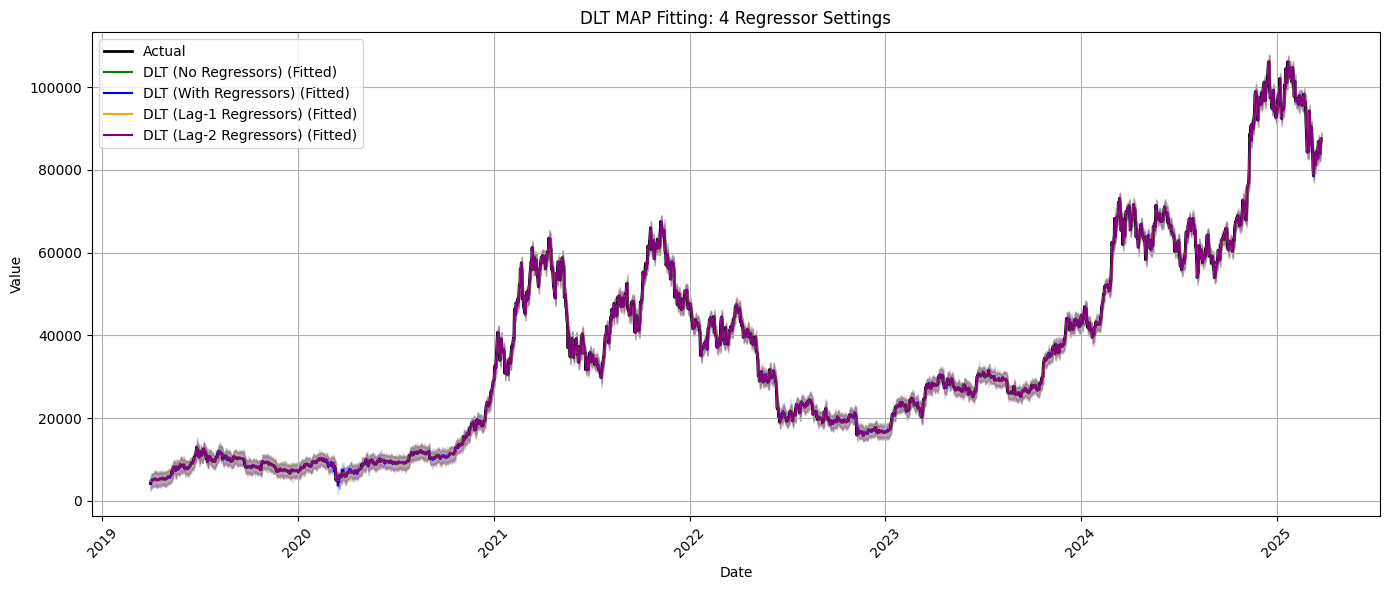

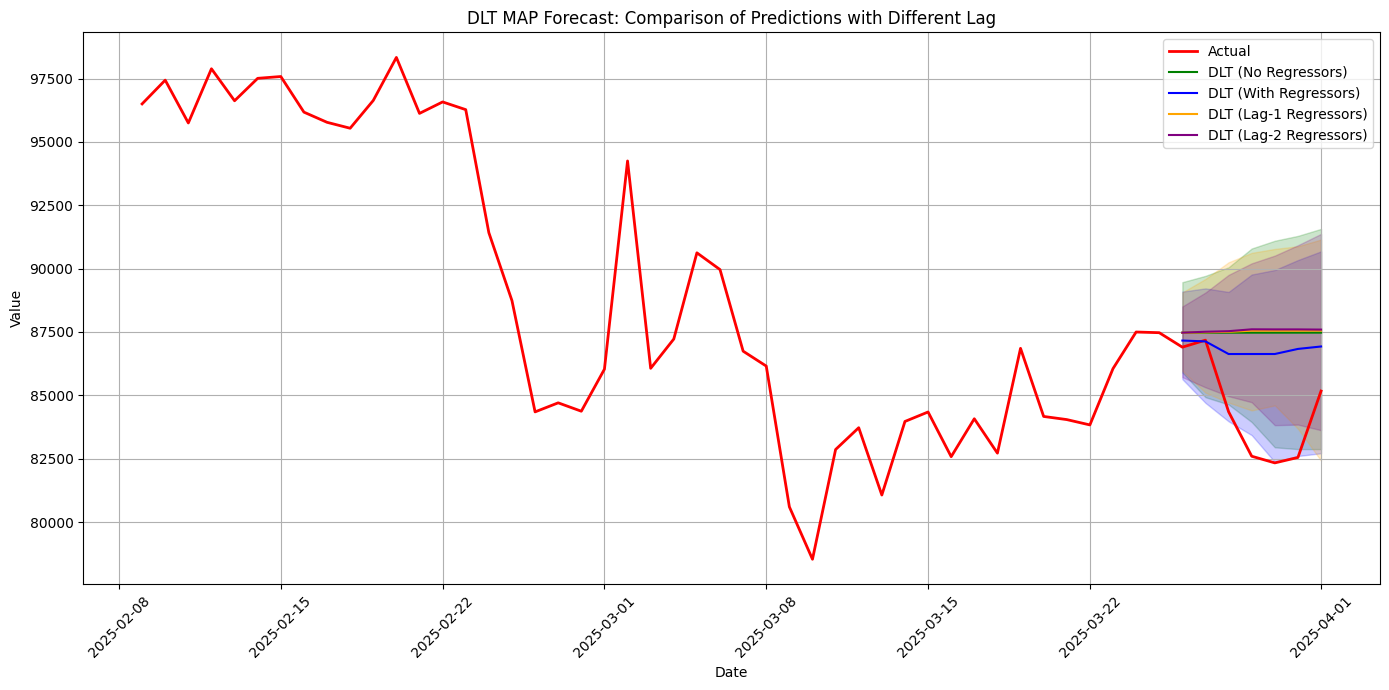

=== DLT (No Regressors) Performance ===
MSPE: 12841378.5923
MAE:  3032.8649
MAPE: 0.0364
PM:   3.5264
----------------------------------------
=== DLT (With Regressors) Performance ===
MSPE: 8773407.4970
MAE:  2422.3853
MAPE: 0.0292
PM:   2.4093
----------------------------------------
=== DLT (Lag-1 Regressors) Performance ===
MSPE: 13253342.3338
MAE:  3083.3312
MAPE: 0.0370
PM:   3.6395
----------------------------------------
=== DLT (Lag-2 Regressors) Performance ===
MSPE: 13537407.5815
MAE:  3119.0839
MAPE: 0.0375
PM:   3.7175
----------------------------------------


In [ ]:
# ========== DLT MAP Model Comparison: All 4 Settings ==========
dlt_models_regression = {}
dlt_predictions_regression = {}

# Step 1: Define all 4 configurations
regression_configs = {
    "no_regressor": {
        "regressor_col": None,
        "label": "DLT (No Regressors)",
        "color": "green"
    },
    "with_regressor": {
        "regressor_col": ['SP500', 'Gold'],
        "label": "DLT (With Regressors)",
        "color": "blue"
    },
    "lag1_regressor": {
        "regressor_col": ['SP500_t-1', 'Gold_t-1'],
        "label": "DLT (Lag-1 Regressors)",
        "color": "orange"
    },
    "lag2_regressor": {
        "regressor_col": ['SP500_t-1', 'SP500_t-2', 'Gold_t-1', 'Gold_t-2'],
        "label": "DLT (Lag-2 Regressors)",
        "color": "purple"
}
}

# Step 2: Split all 4 datasets into train/test
no_reg_df = merged_df[['Date', 'y']].copy()
with_reg_df = merged_df[['Date', 'y', 'SP500', 'Gold']].copy()

no_reg_train = no_reg_df.iloc[:-7].reset_index(drop=True)
no_reg_test = no_reg_df.iloc[-7:].reset_index(drop=True)

with_reg_train = with_reg_df.iloc[:-7].reset_index(drop=True)
with_reg_test = with_reg_df.iloc[-7:].reset_index(drop=True)

lag1_train = lag1_df.iloc[:-7].reset_index(drop=True)
lag1_test = lag1_df.iloc[-7:].reset_index(drop=True)

lag2_train = lag2_full_df.iloc[:-7].reset_index(drop=True)
lag2_test = lag2_full_df.iloc[-7:].reset_index(drop=True)

# Step 3: Training + Prediction
for key, config in regression_configs.items():
    print(f"Training {config['label']}")

    # Assign correct dataset
    if key == 'no_regressor':
        train_data_r = no_reg_train
        test_data_r = no_reg_test
    elif key == 'with_regressor':
        train_data_r = with_reg_train
        test_data_r = with_reg_test
    elif key == 'lag1_regressor':
        train_data_r = lag1_train
        test_data_r = lag1_test
    elif key == 'lag2_regressor':
        train_data_r = lag2_train
        test_data_r = lag2_test

    model = DLT(
        seasonality=None,
        response_col='y',
        date_col='Date',
        regressor_col=config['regressor_col'],
        estimator='stan-map',
        seed=8888,
        global_trend_option='loglinear',
        damped_factor=0.8,
        n_bootstrap_draws=100,
        prediction_percentiles=[5, 95],
    )

    model.fit(train_data_r)
    prediction = model.predict(test_data_r)

    dlt_models_regression[key] = model
    dlt_predictions_regression[key] = prediction

# ========== Plotting Fitting ==========
plt.figure(figsize=(14, 6))
plt.plot(no_reg_train['Date'], no_reg_train['y'], label='Actual', color='black', linewidth=2)

for key, config in regression_configs.items():
    model = dlt_models_regression[key]
    if key == 'no_regressor':
        fitted = model.predict(no_reg_train)
    elif key == 'with_regressor':
        fitted = model.predict(with_reg_train)
    elif key == 'lag1_regressor':
        fitted = model.predict(lag1_train)
    elif key == 'lag2_regressor':
        fitted = model.predict(lag2_train)

    plt.plot(fitted['Date'], fitted['prediction'], label=f"{config['label']} (Fitted)", color=config['color'])
    if 'prediction_5' in fitted.columns:
        plt.fill_between(fitted['Date'], fitted['prediction_5'], fitted['prediction_95'],
                         color=config['color'], alpha=0.15)

plt.title("DLT MAP Fitting: 4 Regressor Settings")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ========== Plotting Predictions ==========
plt.figure(figsize=(14, 7))

# Use actual from no_reg for plotting
actual_extended = pd.concat([no_reg_train.tail(45), no_reg_test], ignore_index=True)
plt.plot(actual_extended['Date'], actual_extended['y'], label='Actual', color='red', linewidth=2)

for key, config in regression_configs.items():
    pred = dlt_predictions_regression[key]
    plt.plot(pred['Date'], pred['prediction'], label=config['label'], color=config['color'])
    plt.fill_between(pred['Date'], pred['prediction_5'], pred['prediction_95'],
                     color=config['color'], alpha=0.2)

plt.title("DLT MAP Forecast: Comparison of Predictions with Different Lag")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for key, config in regression_configs.items():
    pred = dlt_predictions_regression[key]
    if key == 'no_regressor':
        y_true = no_reg_test['y']
    elif key == 'with_regressor':
        y_true = with_reg_test['y']
    elif key == 'lag1_regressor':
        y_true = lag1_test['y']
    elif key == 'lag2_regressor':
        y_true = lag2_test['y']
    evaluate_performance(y_true, pred['prediction'], config['label'])


The current ranking is: DLT with contemporaneous regressors > DLT without regressors > lag-1 > lag-2.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# ========== Prepare for Granger Test ==========
# For Gold_t-1 → BTC
df_lag1_gc = lag1_df[['y', 'Gold_t-1']].copy()
df_lag1_gc.columns = ['BTC', 'Gold']
print("\n=== Granger Test: Gold_t-1 → BTC ===")
grangercausalitytests(df_lag1_gc, maxlag=1)

# For SP500_t-1 → BTC
df_lag1_sp = lag1_df[['y', 'SP500_t-1']].copy()
df_lag1_sp.columns = ['BTC', 'SP500']
print("\n=== Granger Test: SP500_t-1 → BTC ===")
grangercausalitytests(df_lag1_sp, maxlag=1)

# For Gold_t-2 → BTC
df_lag2_gc = lag2_full_df[['y', 'Gold_t-2']].copy()
df_lag2_gc.columns = ['BTC', 'Gold']
print("\n=== Granger Test: Gold_t-2 → BTC ===")
grangercausalitytests(df_lag2_gc, maxlag=1)

# For SP500_t-2 → BTC
df_lag2_sp = lag2_full_df[['y', 'SP500_t-2']].copy()
df_lag2_sp.columns = ['BTC', 'SP500']
print("\n=== Granger Test: SP500_t-2 → BTC ===")
grangercausalitytests(df_lag2_sp, maxlag=1)




=== Granger Test: Gold_t-1 → BTC ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.7734  , p=0.0522  , df_denom=2188, df_num=1
ssr based chi2 test:   chi2=3.7786  , p=0.0519  , df=1
likelihood ratio test: chi2=3.7753  , p=0.0520  , df=1
parameter F test:         F=3.7734  , p=0.0522  , df_denom=2188, df_num=1

=== Granger Test: SP500_t-1 → BTC ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.0751  , p=0.0138  , df_denom=2188, df_num=1
ssr based chi2 test:   chi2=6.0834  , p=0.0136  , df=1
likelihood ratio test: chi2=6.0750  , p=0.0137  , df=1
parameter F test:         F=6.0751  , p=0.0138  , df_denom=2188, df_num=1

=== Granger Test: Gold_t-2 → BTC ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4.0200  , p=0.0451  , df_denom=2187, df_num=1
ssr based chi2 test:   chi2=4.0255  , p=0.0448  , df=1
likelihood ratio test: chi2=4.0218  , p=0.0449  , df=1
parameter F test:         F=4.0200  , p=0.0451 

{1: ({'ssr_ftest': (6.102596304946001, 0.013574111646277651, 2187.0, 1),
   'ssr_chi2test': (6.1109674932929785, 0.013434556810801792, 1),
   'lrtest': (6.102457310822501, 0.013499403814828153, 1),
   'params_ftest': (6.10259630494572, 0.013574111646281521, 2187.0, 1.0)},
   array([[0., 1., 0.]])])}

SP500 has clear Granger-causal influence on BTC at both lag-1 and lag-2, while Gold affects BTC only at lag-2, not at lag-1.

### DLT_R_Refine (contemporaneous)

Returns the coefficient (regression weight) for each regressor, indicating the magnitude and direction of its impact on the target variable (y). The goal is to further refine the DLT-R model. Due to the previous lag analysis of the regression data, we have decided to use contemporaneous data for the subsequent analysis

In [ ]:
dlt_models_regression["with_regressor"].get_regression_coefs()

,regressor,regressor_sign,coefficient
0,SP500,Regular,4.77969
1,Gold,Regular,1.44722


Regular means the prior distribution for
𝛽 is a normal distribution with mean 0 and variance
𝜎^2

In [ ]:
# recall ds
train_data_r = merged_df.iloc[:-7].reset_index(drop=True)
test_data_r = merged_df.iloc[-7:].reset_index(drop=True)

sigma_sp500 = np.std(train_data_r['SP500'])
sigma_gold = np.std(train_data_r['Gold'])

print(sigma_sp500)
print(sigma_gold)


892.9481321447557
353.7571065461924


It calculates the standard deviation for each of the regressors in the training data. These standard deviations are then assigned to the `regressor_sigma_prior`, which is used to specify the prior distributions for the coefficients of the regressors in the model.

2025-11-01 21:32:52 - orbit - INFO - Optimizing (CmdStanPy) with algorithm: LBFGS.
INFO:orbit:Optimizing (CmdStanPy) with algorithm: LBFGS.


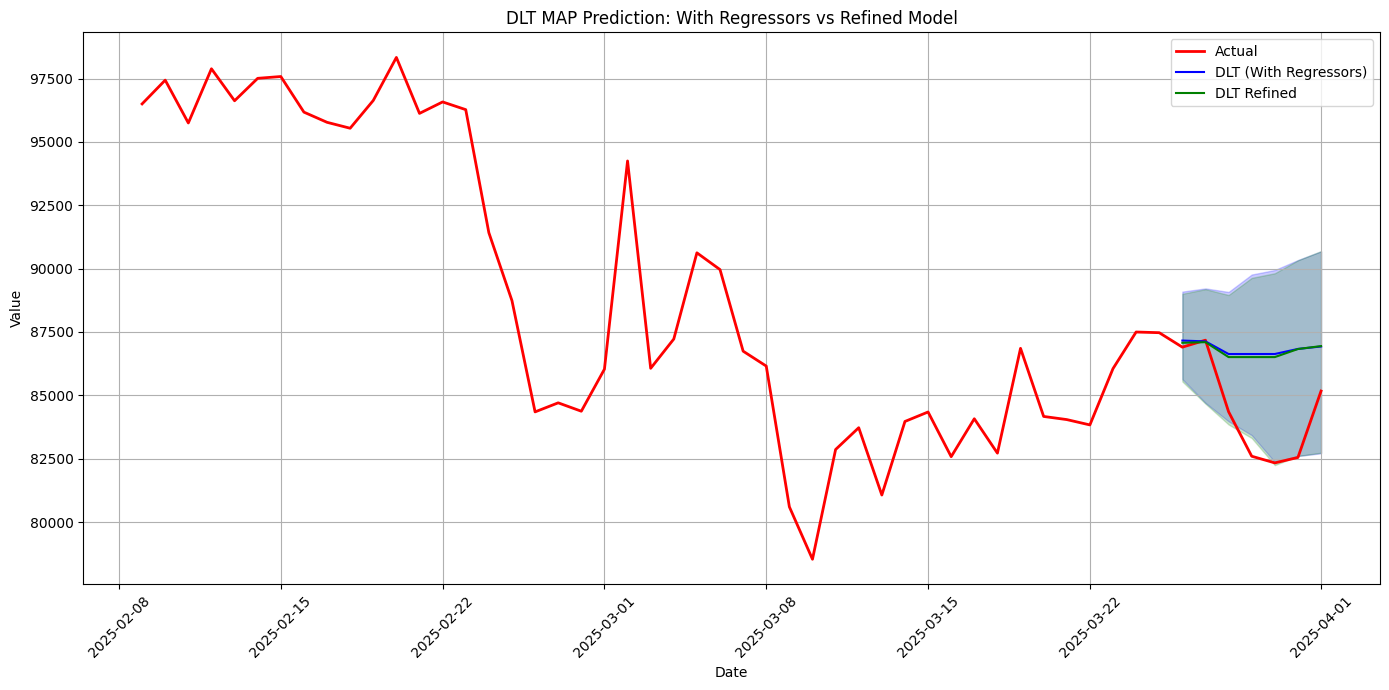

=== DLT (With Regressors) Performance ===
MSPE: 8773407.4970
MAE:  2422.3853
MAPE: 0.0292
PM:   2.4093
----------------------------------------
=== DLT (With Regressors) Refined Performance ===
MSPE: 8409390.0828
MAE:  2363.5656
MAPE: 0.0285
PM:   2.3093
----------------------------------------


In [ ]:
# ========== Define Refined DLT Regression Model ==========

dlt_reg_adjust = DLT(
    seasonality=None,
    response_col='y',
    date_col='Date',
    regressor_col=['SP500', 'Gold'],
    regressor_sign=['=','='],
    regressor_sigma_prior=[893, 354],
    global_trend_option='loglinear',
    damped_factor=0.8,
    n_bootstrap_draws=100,
    prediction_percentiles=[5, 95],
    estimator='stan-map',
    seed=8888,
)

# Fit the refined model
dlt_reg_adjust.fit(df=train_data_r)
predicted_df_reg_adjust = dlt_reg_adjust.predict(test_data_r)

# ========== Add Refined Model to Dictionary for Comparison ==========

# Store the refined model in the existing dictionary
dlt_models_regression["refined"] = dlt_reg_adjust
dlt_predictions_regression["refined"] = predicted_df_reg_adjust

# ========== Plot Prediction Comparison: Base vs Refined Regression ==========

plt.figure(figsize=(14, 7))

# Combine recent train + test for actual line
actual_extended = pd.concat([train_data_r.tail(45), test_data_r], ignore_index=True)
plt.plot(actual_extended['Date'], actual_extended['y'], label='Actual', color='red', linewidth=2)

# Plot predictions from DLT with Regressors
base_pred = dlt_predictions_regression["with_regressor"]
plt.plot(base_pred['Date'], base_pred['prediction'], label='DLT (With Regressors)', color='blue')
plt.fill_between(base_pred['Date'], base_pred['prediction_5'], base_pred['prediction_95'],
                 color='blue', alpha=0.2)

# Plot predictions from DLT Refined model
refined_pred = dlt_predictions_regression["refined"]
plt.plot(refined_pred['Date'], refined_pred['prediction'], label='DLT Refined', color='green')
plt.fill_between(refined_pred['Date'], refined_pred['prediction_5'], refined_pred['prediction_95'],
                 color='green', alpha=0.2)

plt.title("DLT MAP Prediction: With Regressors vs Refined Model")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ========== Prediction Performance Evaluation ==========

# Evaluate and compare performance between models
evaluate_performance(test_data_r['y'], base_pred['prediction'], "DLT (With Regressors)")
evaluate_performance(test_data_r['y'], refined_pred['prediction'], "DLT (With Regressors) Refined")


By adding informative priors, the refined model not only beat the naive regressor model but also outdid the original baseline, achieving the best overall performance. This indicates that the refined model is effective.

## Comprehensive comparison

In this section,we provide a comprehensive comparison between the DLT-R Refined and Prophet models, considering all components including changepoints, regressors, seasonality, and holidays.



In [ ]:
# ========== Prepare Data for Prophet ==========
# Prophet requires the date column to be named 'ds' and target column as 'y' (already named correctly)
prophet_train = train_data_r.rename(columns={'Date': 'ds'})
prophet_test = test_data_r.rename(columns={'Date': 'ds'})

# ========== Create and Configure Prophet Model ==========
changepoints = ['2020-03-12', '2020-12-16', '2021-05-19', '2021-11-10',
                '2022-05-09', '2022-11-11', '2023-03-13', '2024-12-05']
prophet_model = Prophet(
    weekly_seasonality=False,
    yearly_seasonality=False,
    changepoints=changepoints
).add_seasonality(name='monthly', period=30.5, fourier_order=5)
# Add external regressors (SP500 and Gold)
prophet_model.add_regressor('SP500')
prophet_model.add_regressor('Gold')

# ========== Fit the Model ==========
prophet_model.fit(prophet_train)

# ========== Forecast ==========
# Future dataframe must contain 'ds' and the external regressors used during training
future = prophet_test[['ds', 'SP500', 'Gold']]
forecast = prophet_model.predict(future)

# ========== Store Prediction Results ==========
# Add forecasted values and prediction intervals to the test set
prophet_test['prediction'] = forecast['yhat']
prophet_test['prediction_5'] = forecast['yhat_lower']
prophet_test['prediction_95'] = forecast['yhat_upper']


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


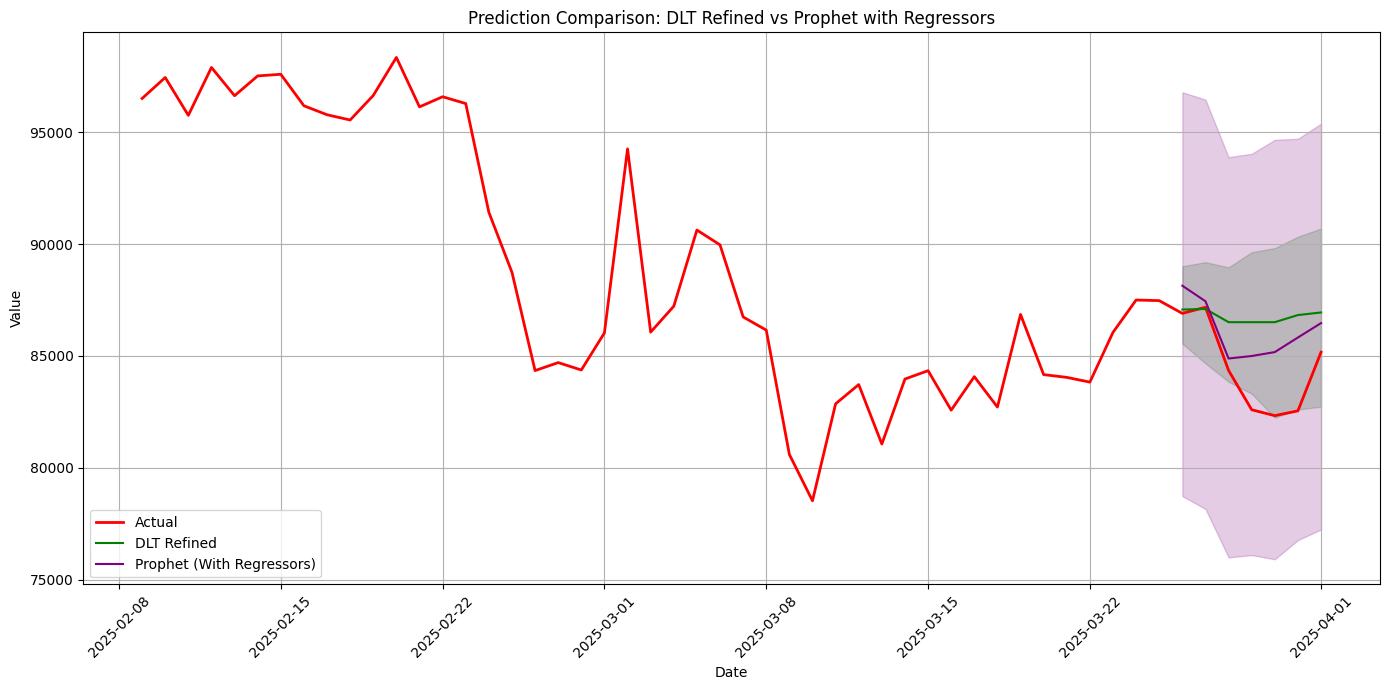

In [ ]:
plt.figure(figsize=(14, 7))

plt.plot(actual_extended['Date'], actual_extended['y'], label='Actual', color='red', linewidth=2)

# DLT Refined
plt.plot(refined_pred['Date'], refined_pred['prediction'], label='DLT Refined', color='green')
plt.fill_between(refined_pred['Date'], refined_pred['prediction_5'], refined_pred['prediction_95'],
                 color='green', alpha=0.2)

# Prophet
plt.plot(prophet_test['ds'], prophet_test['prediction'], label='Prophet (With Regressors)', color='purple')
plt.fill_between(prophet_test['ds'], prophet_test['prediction_5'], prophet_test['prediction_95'],
                 color='purple', alpha=0.2)

plt.title("Prediction Comparison: DLT Refined vs Prophet with Regressors")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Evaluate and compare performance between models
evaluate_performance(test_data_r['y'], refined_pred['prediction'], "DLT (With Regressors) Refined")
evaluate_performance(prophet_test['y'], prophet_test['prediction'], "Prophet (With Regressors)")

=== DLT (With Regressors) Refined Performance ===
MSPE: 8399507.4486
MAE:  2362.1185
MAPE: 0.0284
PM:   2.3066
----------------------------------------
=== Prophet (With Regressors) Performance ===
MSPE: 4971485.7744
MAE:  1956.4752
MAPE: 0.0234
PM:   1.3652
----------------------------------------


To evaluate the predictive performance of our time series forecasting models, we implemented both a refined DLTR Refined model and the Prophet model, each incorporating external regressors including SP500 and Gold, as well as national holidays (for Prophet).

The Prophet model included weekly and daily seasonality, a changepoint prior scale of 0.05, and holiday effects based on U.S. public holidays. Overall, the refined DLT model demonstrated the better predictive accuracy compared to Prophet.

## Comparison II: Without Regressors

In [ ]:

# ========== Prepare Data for Prophet ==========
# Create a copy of the merged dataframe with 'Date' and 'y' columns
no_reg_df = merged_df[['Date', 'y']].copy()

# Prepare the data for Prophet (rename columns as required by Prophet)
prophet_train_wor = no_reg_df.iloc[:-7].rename(columns={'Date': 'ds'}).reset_index(drop=True)
prophet_test_wor = no_reg_df.iloc[-7:].rename(columns={'Date': 'ds'}).reset_index(drop=True)

# ========== Create and Configure Prophet Model Without Regressors ==========
prophet_model_no_regressor = Prophet(
    interval_width=0.95,           # 95% prediction interval
    yearly_seasonality=False,#
    weekly_seasonality=False,       # Enable weekly seasonality
    daily_seasonality=False,
    changepoints=[
        '2020-03-12', '2020-12-16', '2021-05-19',
        '2021-11-10', '2022-05-09', '2022-11-11',
        '2023-03-13', '2024-12-05'
    ]
).add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Add US national holidays as additional regressors (optional)
#prophet_model_no_regressor.add_country_holidays(country_name='US')

# ========== Fit the Model ==========
prophet_model_no_regressor.fit(prophet_train_wor)

# ========== Forecast ==========
# Future dataframe must contain 'ds' for prediction
future_no_regressor = prophet_test_wor[['ds']]
forecast_no_regressor = prophet_model_no_regressor.predict(future_no_regressor)

# ========== Store Prediction Results ==========
# Add forecasted values and prediction intervals to the test set
prophet_test_wor['prediction'] = forecast_no_regressor['yhat']
prophet_test_wor['prediction_5'] = forecast_no_regressor['yhat_lower']
prophet_test_wor['prediction_95'] = forecast_no_regressor['yhat_upper']

# ========== Prediction Performance Evaluation ==========
# call dlt model without regressors
no_regressor_model = dlt_models_regression["no_regressor"]
no_regressor_prediction = no_regressor_model.predict(test_data_r)


evaluate_performance(test_data_r['y'], no_regressor_prediction['prediction'], "DLT (No Regressors)")
evaluate_performance(prophet_test_wor['y'], prophet_test_wor['prediction'], "Prophet (No Regressors)")



=== DLT (No Regressors) Performance ===
MSPE: 12841518.6508
MAE:  3032.8880
MAPE: 0.0364
PM:   3.5264
----------------------------------------
=== Prophet (No Regressors) Performance ===
MSPE: 84569141.2506
MAE:  8960.4942
MAPE: 0.1067
PM:   23.2236
----------------------------------------


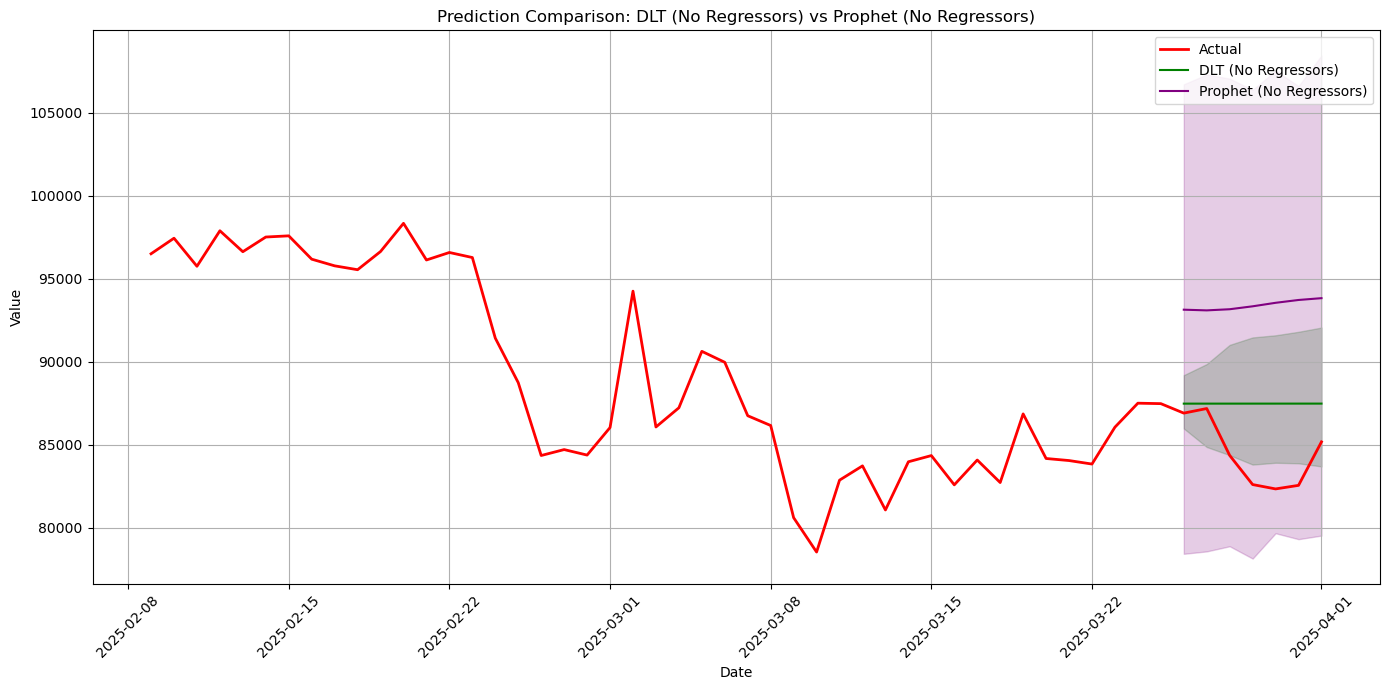

In [ ]:
plt.figure(figsize=(14, 7))

# Plot actual data
plt.plot(actual_extended['Date'], actual_extended['y'], label='Actual', color='red', linewidth=2)

# Plot DLT Refined predictions
plt.plot(no_regressor_prediction['Date'], no_regressor_prediction['prediction'], label='DLT (No Regressors)', color='green')
plt.fill_between(no_regressor_prediction['Date'], no_regressor_prediction['prediction_5'], no_regressor_prediction['prediction_95'],
                 color='green', alpha=0.2)

# Plot Prophet predictions without regressors
plt.plot(prophet_test_wor['ds'], prophet_test_wor['prediction'], label='Prophet (No Regressors)', color='purple')
plt.fill_between(prophet_test_wor['ds'], prophet_test_wor['prediction_5'], prophet_test_wor['prediction_95'],
                 color='purple', alpha=0.2)

# Title and labels
plt.title("Prediction Comparison: DLT (No Regressors) vs Prophet (No Regressors)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
